# Avance 1: Análisis exploratorio del corpus normativo y catalogos regulatorios

La Dirección de Información del Sistema Financiero (DISF), adscrita al Banco de México, se encarga de recabar, generar y analizar información de las instituciones financieras con objeto de coadyuvar a cumplir al Banco con sus finalidades.

El acopio de datos se realiza a través de requerimientos de información, los cuales deben diseñarse con base en marcos regulatorios como la Ley de Instituciones de Crédito, la Circular Única de Bancos, disposiciones y circulares, así como en estándares internacionales y lineamientos internos.

El proceso de diseño implica traducir disposiciones normativas en estructuras de datos denominadas formularios, catálogos asociados, validaciones técnicas y de negocio, y documentación detallada de apoyo para las instituciones. Actualmente, este proceso es intensivo en conocimiento, altamente manual y puede presentar inconsistencias entre equipos.

En este contexto, surge la necesidad de explorar herramientas basadas en inteligencia artificial que permitan apoyar con el análisis de documentos regulatorios y facilitar la estructuración de requerimientos de información. El presente proyecto integrador propone el desarrollo de un modelo que asista al personal de la DISF en el diseño y mejora de requerimientos de información, promoviendo eficiencia, consistencia y estandarización.

El alcance de este proyecto no contempla la generación de las validaciones técnicas, de negocio ni de las ayudas genéricas debido a que se trata de una primera aproximación técnica hacia el desarrollo de una herramienta más completa.

Este cuaderno documenta el primer avance del proyecto enfocado en la automatización del diseño de requerimientos de información financiera mediante técnicas de Procesamiento de Lenguaje Natural (NLP) y agentes basados en modelos de lenguaje. A diferencia de un problema tabular tradicional, la unidad de analisis principal es un corpus normativo en formato Markdown, complementado por catalogos regulatorios estructurados en formato tabular.

El objetivo es realizar el análisis exploratorio de los insumos principales del proyecto: documentos regulatorios, formularios existentes que se derivaron de dichos documentos y sus catálogos asociados.

Desde una perspectiva metodológica, la fase equivalente al Análisis Exploratorio de Datos (EDA) consiste en caracterizar la calidad del corpus, su estructura, cardinalidad y relaciones entre los insumos. Esta labor es relevante porque permite reducir la complejidad semántica, y sentar bases reproducibles para las etapas posteriores como la recuperación de información, representación semántica y diseño automatizado de formularios.

## EDA en el contexto de NLP

Dado que la naturaleza de este proyecto se basa en el **Procesamiento de Lenguaje Natural (NLP)** y en la generación estructurada de información, el Análisis Exploratorio de Datos (EDA) no se limita únicamente a datos tabulares, sino que se extiende a tres tipos de insumos:

1. Texto normativo (no estructurado)
2. Formularios regulatorios (estructuras tabulares por secciones)
3. Catálogos asociados (dominios de valores)

Por ello, los conceptos tradicionales del EDA se reinterpretan de la siguiente manera:

---

###  Valores faltantes
En el corpus normativo, los valores faltantes se interpretan como párrafos vacíos o errores de extracción en la conversión PDF/Word a Markdown.  
En los formularios, corresponden a campos sin definición completa (por ejemplo, ausencia de descripción, tipo de dato o catálogo).  
En los catálogos, se analizan como registros incompletos o inconsistentes dentro de los dominios de valores.

---

###  Estadísticas resumidas
En el texto regulatorio, se analizan métricas como:
- número de caracteres
- número de palabras (tokens)
- número de líneas
- longitud promedio de palabras por segmento

En los formularios:
- número de campos por sección
- tipos de dato más frecuentes
- reutilización de campos entre secciones

En los catálogos:
- cardinalidad (número de registros)
- número de columnas
- distribución de valores

---

###  Valores atípicos (outliers)
En el contexto de NLP, los outliers se interpretan como **ruido documental**, incluyendo:
- encabezados institucionales repetitivos ("Hacienda", "CNBV")
- pies de página
- residuos de conversión (símbolos extraños, saltos de página)

En los formularios, los outliers pueden reflejar:
- campos con estructuras inconsistentes
- definiciones atípicas respecto al resto de las secciones

---

###  Cardinalidad de variables categóricas
Se analiza principalmente a través de los **catálogos regulatorios**, determinando:
- tamaño del espacio de valores permitidos
- complejidad de los dominios de negocio
- diferencias entre catálogos simples y altamente estructurados

---

###  Análisis bi/multivariante (relaciones)
El análisis relacional se amplía a tres niveles:

- Texto -> Catálogos: cobertura semántica del vocabulario regulatorio  
- Formularios -> Catálogos: qué campos dependen de qué catálogos  
- Texto -> Formularios: identificación de conceptos regulatorios reflejados en estructuras tabulares  

Esto permite evaluar en qué medida los formularios existentes reflejan explícitamente la regulación.

---

###  Distribuciones y sesgos
Se analizan:
- distribución de longitud de segmentos del texto
- distribución de tipos de campos en formularios
- distribución de tamaños de catálogos

Esto permite identificar sesgos estructurales y heterogeneidad en los datos.

---

###  Tendencias estructurales
Aunque no se trabaja con series de tiempo, se identifican patrones estructurales como:
- reutilización de campos entre secciones
- repetición de estructuras tabulares
- patrones de diseño en formularios regulatorios

---

###  Conclusión metodológica
Este enfoque extendido de EDA permite no solo limpiar y entender los datos, sino también **capturar la relación entre regulación, estructuras tabulares y dominios de valores**, lo cual es fundamental para las etapas posteriores de generación automatizada de formularios y catálogos.

## Configuración inicial

In [1]:
from pathlib import Path
import re
import os
import sys
import json
import warnings
import time
import requests

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', palette='Blues')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)


warnings.filterwarnings("ignore")

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'notebooks'
PROJECT_ROOT = NOTEBOOK_DIR.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_RAW = PROJECT_ROOT / "data" / "01_raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "02_interim"

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_INTERIM.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)

## Conversión de PDFs a Mardown a través de la herramienta Blazedocs

Los documentos regulatorios originales se encuentran en formato PDF. Para facilitar su análisis dentro de un flujo de NLP, se convierten a Markdown, ya que este formato conserva mejor la estructura lógica del documento, incluyendo encabezados, párrafos y tablas.

En este proyecto se utiliza BlazeDocs para la conversión de PDFs a Markdown mediante la API de la aplicación, utilizando el siguiente código:

In [ ]:
import requests

BLAZEDOCS_API_URL = "https://blazedocs.io/api/v1/convert"

# Folder con pdfs originales
PDF_INPUT_DIR = DATA_RAW / "pdfs"

# Folder con formularios originales
FORM_INPUT_DIR = DATA_RAW / "formularios"

# Folder con catálogos originales
CAT_INPUT_DIR = DATA_RAW / "catalogos"

# Folder donde se guardan archivos markdown
MARKDOWN_OUTPUT_DIR = DATA_INTERIM / "markdown"

# Folder donde se guardan dataframes
DF_OUTPUT_DIR = DATA_INTERIM / "dataframes"

# Crear folder si no existe
PDF_INPUT_DIR.mkdir(parents=True, exist_ok=True)
FORM_INPUT_DIR.mkdir(parents=True, exist_ok=True)
CAT_INPUT_DIR.mkdir(parents=True, exist_ok=True)
MARKDOWN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"PDF input folder: {PDF_INPUT_DIR}")
print(f"Forms input folder: {FORM_INPUT_DIR}")
print(f"Catalogs input folder: {CAT_INPUT_DIR}")

print(f"Markdown output folder: {MARKDOWN_OUTPUT_DIR}")
print(f"Dataframes output folder: {DF_OUTPUT_DIR}")

Project root: /content
PDF input folder: /content/data/01_raw/pdfs
Forms input folder: /content/data/01_raw/formularios
Catalogs input folder: /content/data/01_raw/catalogos
Markdown output folder: /content/data/02_interim/markdown
Dataframes output folder: /content/data/02_interim/dataframes


**Conexión con API Key de BlazeDocs**

In [ ]:
import dotenv
dotenv_path = PROJECT_ROOT / "env.txt"
dotenv.load_dotenv(dotenv_path=dotenv_path)

def get_blazedocs_api_key() -> str:
    """
    Se toma la API key de BlazeDocs desde una variable de ambiente
    """
    api_key = os.getenv("BLAZEDOCS_API_KEY")

    if not api_key:
        raise ValueError(
            "No se encontró la API key")

    return api_key

**Función que convierte un PDF a formato Markdown**

In [ ]:
def convert_pdf_to_markdown(pdf_path: Path) -> dict:
    """
    pdf_path : Path al archivo PDF
    devuelve un diccionario con el texto markdown y los metadatos que regresa la API.
        Path to the PDF file.
    """
    api_key = get_blazedocs_api_key()


    headers = {
        "Authorization": f"Bearer {api_key}"}

    with open(pdf_path, "rb") as file:
        files = {
            "file": (pdf_path.name, file, "application/pdf")

        }


        response = requests.post(
            BLAZEDOCS_API_URL,
            headers=headers,
            files=files
        )

    # Error si falla el request HTTP
    response.raise_for_status()

    result = response.json()

    # Indica si se realizó la conversión correctamente o si se generó un error
    if not result.get("success", False):
        raise ValueError(
            f"BlazeDocs conversion failed for {pdf_path.name}: "
            f"{result.get('error', 'Unknown error')}"
        )

    return result

**Función para guardar el archivo Markdown convertido**

In [ ]:
def save_markdown(markdown_text: str, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_path, "w", encoding="utf-8") as file:
        file.write(markdown_text)

**Función para convertir todos los PDFs encontrados en un folder a markdown y guardarlos en otro folder**

In [ ]:
def convert_pdf_folder_to_markdown(
    input_dir: Path,
    output_dir: Path,
    overwrite: bool = False,
    pause_seconds: float = 1.0
) -> pd.DataFrame:
    """
    Convierte los documentos encontrados en una carpeta en Markdown.

    input_dir : Directorio donde se encuentran los PDFs.
    output_dir : Directorio donde se guardan los archivos convertidos.
    overwrite : booleano. Si es falso, los archivos ya convertidos encontrados, no se convierten de nuevo.
    pause_seconds : float. Segundos de espera entre llamadas a la API.

    Devuelve un pd.DataFrame con los registros de conversión por cada PDF encontrado.
    """
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)

    pdf_files = sorted(input_dir.glob("*.pdf"))

    if not pdf_files:
        raise FileNotFoundError(f"No PDF files were found in: {input_dir}")

    conversion_log = []

    for pdf_path in pdf_files:
        output_path = output_dir / f"{pdf_path.stem}.md"

        if output_path.exists() and not overwrite:
            conversion_log.append({
                "file_name": pdf_path.name,
                "output_file": output_path.name,
                "status": "skipped_already_exists",
                "page_count": None,
                #"token_count": None,
                "processing_time_ms": None,
                "error": None
            })
            continue

        try:
            result = convert_pdf_to_markdown(pdf_path)

            data = result["data"]
            markdown_text = data["markdown"]

            save_markdown(markdown_text, output_path)

            conversion_log.append({
                "file_name": pdf_path.name,
                "output_file": output_path.name,
                "status": "success",
                "page_count": data.get("page_count"),
                "token_count": data.get("token_count"),
                "processing_time_ms": data.get("processing_time_ms"),
                "error": None
            })

            time.sleep(pause_seconds)

        except Exception as e:
            conversion_log.append({
                "file_name": pdf_path.name,
                "output_file": output_path.name,
                "status": "error",
                "page_count": None,
                "token_count": None,
                "processing_time_ms": None,
                "error": str(e)
            })

    return pd.DataFrame(conversion_log)

**Conversión de archivos**

En este paso se realiza la conversión de los archivos pdf encontrados en el directorio a Markdown:

In [ ]:
conversion_log = convert_pdf_folder_to_markdown(
    input_dir=PDF_INPUT_DIR,
    output_dir=MARKDOWN_OUTPUT_DIR,
    overwrite=False
)

Se observa que la conversión fue exitosa

In [ ]:
conversion_log

,file_name,output_file,status,page_count,token_count,processing_time_ms,error
0,LeyInstCredito_93-110.pdf,LeyInstCredito_93-110.md,success,18,14503,5620,None
1,Circular3-2012.pdf,Circular3-2012.md,success,313,173386,38341,None
2,Anexo_33_CUB.pdf,Anexo_33_CUB.md,success,100,78013,14063,None
3,CUB_extracto.pdf,CUB_extracto.md,success,29,18750,6774,None
4,Disposiciones_Liquidez.pdf,Disposiciones_Liquidez.md,success,73,46406,9632,None
5,Intraday_Liquidity_esp.pdf,Intraday_Liquidity_esp.md,success,26,10350,5090,None


---

**Función para leer un archivo Markdown convertido previamente**

Para evitar realizar la conversión cada que se ejecuta este código, se implementan funciones que permiten recuperar los archivos Markdown convertidos con anterioridad.

In [ ]:
def read_markdown_file(markdown_path: Path) -> dict:
    """
    Lee un archivo markdown convertido previamente como diccionario.
    """
    with open(markdown_path, "r", encoding="utf-8") as file:
        text = file.read()

    return {
        "file_name": markdown_path.name,
        "file_stem": markdown_path.stem,
        "file_path": str(markdown_path),
        "text": text,
        "character_count": len(text),
        "word_count": len(text.split())
    }

**Función para leer todos los archivos Markdown encontrados en una carpeta**

In [ ]:
def read_markdown_folder(markdown_dir: Path) -> pd.DataFrame:
    """
    Lee todos los archivos markdown y los almacena en un DataFrame.
    """
    markdown_dir = Path(markdown_dir)

    markdown_files = sorted(markdown_dir.glob("*.md"))

    if not markdown_files:
        raise FileNotFoundError(f"No Markdown files were found in: {markdown_dir}")

    documents = []

    for markdown_path in markdown_files:
        documents.append(read_markdown_file(markdown_path))

    return pd.DataFrame(documents)

**Carga de pdfs convertidos a dataframe**

In [ ]:
markdown_df = read_markdown_folder(MARKDOWN_OUTPUT_DIR)

In [ ]:
markdown_df.head()

,file_name,file_stem,file_path,text,character_count,word_count
0,Anexo_33_CUB.md,Anexo_33_CUB,/content/data/02_interim/markdown/Anexo_33_CUB.md,Pág. 1\n\n(364) ANEXO 33\n\nCONTENIDO\n\nSerie A. Criterios relativos al esquema general de la contabilidad para ins...,344416,53880
1,CUB_extracto.md,CUB_extracto,/content/data/02_interim/markdown/CUB_extracto.md,Hacienda Secretaría de Hacienda y Crédito Público\n\nCNBV\n\nCONSEJO NACIONAL BANCEDAR PRESIDENCIA Y DE VIGILANZA\n\...,81971,13639
2,Circular3-2012.md,Circular3-2012,/content/data/02_interim/markdown/Circular3-2012.md,BANCO DE MÉXICO®\n\nTEXTO COMPILADO de la Circular 3/2012 publicada en el Diario Oficial de la Federación el 2 de ma...,760798,120695
3,Disposiciones_Liquidez.md,Disposiciones_Liquidez,/content/data/02_interim/markdown/Disposiciones_Liquidez.md,BANCO DE MÉXICO\n\nTEXTO COMPILADO de las Disposiciones de carácter general sobre los Requerimientos de Liquidez par...,204119,32902
4,Intraday_liquidity_esp.md,Intraday_liquidity_esp,/content/data/02_interim/markdown/Intraday_liquidity_esp.md,Herramientas de monitoreo para la gestión de la liquidez intradía - traducción al español\nPágina 1 de 16\n\nComité ...,45439,7501


## Lectura de formularios y sus catálogos asociados en Excel como diccionarios de DataFrames estructurados

El formato en el que se encuentran los documentos asociados a los formularios son:

* Formularios: Archivos xlsx. Una pestaña por sección (tabla).
* Catálogos: Archivos xlsx. Una pestaña por catálogo.



In [ ]:
def leer_excel_multipestana(path_excel: str, tipo: str) -> dict:
    """
    Función para leer cada pestaña de un excel
    path_excel : Ruta del archivo Excel.
    tipo : 'formulario' o 'catalogo', solo para metadatos.

    Devuelve un diccionario de dataframes donde cada una corresponde a una sección o un catálogo

    """
    path_excel = Path(path_excel)

    if not path_excel.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {path_excel}")

    xls = pd.ExcelFile(path_excel)
    tablas = {}

    for sheet in xls.sheet_names:
        df = pd.read_excel(path_excel, sheet_name=sheet)

        # Limpieza básica de nombres de columnas
        df.columns = [
            str(c).strip().lower().replace(" ", "_")
            for c in df.columns
        ]

        # Eliminar filas completamente vacías
        df = df.dropna(how="all").reset_index(drop=True)

        # Guardar metadatos útiles
        df.attrs["archivo"] = path_excel.name
        df.attrs["tipo"] = tipo
        df.attrs["sheet"] = sheet

        tablas[sheet] = df

    return tablas

**Lectura de formularios**

Se definen los directorios donde se encuentran los formularios y sus catálogos asociados

In [ ]:

formulario_ml_path = FORM_INPUT_DIR / "formulario_ml.xlsx"
formulario_fe_path = FORM_INPUT_DIR / "formulario_fe.xlsx"
formulario_lid_path = FORM_INPUT_DIR / "formulario_lid.xlsx"

catalogo_ml_path = CAT_INPUT_DIR / "catalogos_ml.xlsx"
catalogo_fe_path = CAT_INPUT_DIR / "catalogos_fe.xlsx"
catalogo_lid_path = CAT_INPUT_DIR / "catalogos_lid.xlsx"


* __Formulario Manejo de Liquidez (ML)__

A partir de este formulario, se solicita a cada institución de banca múltiple y de desarrollo que provean todos los insumos detallados necesarios para calcular el Coeficiente de Cobertura de Liquidez (CCL) que es un indicador que representa la salud en la que se encuentra una institución, de acuerdo con los activos líquidos con los que cuente para hacer frente a sus obligaciones en un escenario de estrés de 30 días. Dicho indicador debe ser de al menos el 100%.

Es normado directamente por las Disposiciones de carácter general sobre los Requerimientos de Liquidez para las Instituciones de Banca Múltiple.

Este formulario tiene frecuencia diaria de transmisión.

In [ ]:
formulario_ml = leer_excel_multipestana(formulario_ml_path, tipo="formulario")
catalogo_ml = leer_excel_multipestana(catalogo_ml_path, tipo="catalogo")

print(f"Secciones del formulario detectadas: {len(formulario_ml)}")
print(list(formulario_ml.keys()))

print(f"Catálogos detectados: {len(catalogo_ml)}")
print(list(catalogo_ml.keys()))

display(next(iter(formulario_ml.values())).head())
display(next(iter(catalogo_ml.values())).head())

Secciones del formulario detectadas: 5
['seccion_I_activos_liquidos', 'seccion_II_salidas', 'seccion_III_entradas', 'seccion_IV_computo', 'seccion_C_consolidado']
Catálogos detectados: 6
['entidades_financieras_ml', 'relacion_institucion_filial', 'conceptos_ml', 'concepto_seccion_plazo_ml', 'moneda', 'plazos_ml']


,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1,catalogo_2
0,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN,NaN
1,institucion,clave de la institucion a la cual pertenece la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_financieras_ml,NaN
2,filial,clave de la entidad financiera objeto de consolidacion asociada a la institucion a la cual corresponde la informacion,caracter,6,valores de catalogo,NaN,NaN,NaN,*,relacion_institucion_filial,NaN
3,concepto,clave del concepto de la seccion I al cual corresponde la informacion,numerico,5,valores de catalogo,NaN,NaN,NaN,*,conceptos_ml,concepto_seccion_plazo_ml
4,moneda,clave de la moneda,caracter,3,valores de catalogo,NaN,NaN,NaN,*,moneda,NaN


,clave,nombre
0,37006,bancomext
1,37009,banobras
2,37019,banjercito
3,37135,nafin
4,37166,banco del bienestar


* __Formulario Financiamiento Estable (FE)__

A partir de este formulario, se solicita a cada institución de banca múltiple que provea todos los insumos detallados necesarios para calcular el Coeficiente de Financiamiento Estable Neto (CFEN) que es un indicador que señala si la institución utiliza fuentes de fondeo estables, para financiar adecuadamente sus actividades en función de la cantidad y calidad de su cuantía de activos, los plazos de vencimiento de sus operaciones, la emisión de créditos, entre otros. Este indicador se mide en el largo plazo y debe ser de al menos el 100%.

Es normado directamente por las Disposiciones de carácter general sobre los Requerimientos de Liquidez para las Instituciones de Banca Múltiple.

Este formulario tiene frecuencia mensual de transmisión.

In [ ]:
formulario_fe = leer_excel_multipestana(formulario_fe_path, tipo="formulario")
catalogo_fe = leer_excel_multipestana(catalogo_fe_path, tipo="catalogo")

print(f"Secciones del formulario detectadas: {len(formulario_fe)}")
print(list(formulario_fe.keys()))

print(f"Catálogos detectados: {len(catalogo_fe)}")
print(list(catalogo_fe.keys()))

display(next(iter(formulario_fe.values())).head())
display(next(iter(catalogo_fe.values())).head())

Secciones del formulario detectadas: 4
['seccion_I_FED', 'seccion_II_fer', 'seccion_III_consolidado', 'seccion_IV_computo_cfen']
Catálogos detectados: 6
['entidades_financieras_fe', 'relacion_institucion_filial', 'conceptos_fe', 'concepto_seccion_plazo_fe', 'moneda', 'plazos_fe']


,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1,catalogo_2
0,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN,NaN
1,institucion,clave de la institucion a la cual corresponde la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_fiancieras_fe,NaN
2,subsidiaria,clave de la subsidiaria de la institucion a la cual corresponde la informacion.,caracter,6,valores de catalogo,NaN,NaN,NaN,*,relacion_institucion_filial,NaN
3,concepto,clave del concepto de la seccion I al cual corresponde la informacion,numerico,5,valores de catalogo,NaN,NaN,NaN,*,conceptos_fe,concepto_seccion_plazo_fe
4,moneda,clave de la moneda,caracter,3,valores de catalogo,NaN,NaN,NaN,*,moneda,NaN


,clave,nombre
0,40002,banamex
1,40012,bbva
2,40014,santander
3,40021,hsbc
4,40030,bajio


* __Formulario de Liquidez Intradía (LID)__

A partir de este formulario, se solicita a cada institución de banca múltiple que indique tanto la liquidez disponible al inicio del día, como los tipos de operaciones que podrían generar un riesgo de liquidez en el intradía.

No existe una norma ni regulación oficial mexicana que regule directamente a este formulario. Su diseño surgió a partir del documento denominado "Herramientas de monitoreo de la Liquidez Intradía" emitido por el Comité de Basilea.


In [ ]:
formulario_lid = leer_excel_multipestana(formulario_lid_path, tipo="formulario")
catalogo_lid = leer_excel_multipestana(catalogo_lid_path, tipo="catalogo")

print(f"Secciones del formulario detectadas: {len(formulario_lid)}")
print(list(formulario_lid.keys()))

print(f"Catálogos detectados: {len(catalogo_lid)}")
print(list(catalogo_lid.keys()))

display(next(iter(formulario_lid.values())).head())
display(next(iter(catalogo_lid.values())).head())

Secciones del formulario detectadas: 5
['seccion_I_liquiddisp_inicio_dia', 'seccion_II_liq_hora_especifica', 'seccion_IV_corresponsalia', 'seccion_v_usos_lincred', 'seccion_a']
Catálogos detectados: 13
['entidades_financieras_lid', 'tipo_de_activo_lid', 'moneda', 'clave_valor_lid', 'identificador_pago', 'identificador_liquidacion', 'identificador_horario_liq', 'tipo_obligacion_lid', 'tipo_pago_lid', 'liquidaciones_no_efectuadas', 'contrapartes\xa0', 'seccion_a\xa0\xa0', 'tipo_garantia_lid']


,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1
0,institucion,clave de la institucion a la cual pertenece la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_financieras_lid
1,fecha_corte,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN
2,fecha_datos,fecha de cada dia habil del mes asociado a la fecha_corte,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN
3,clave_tipo,clave para identificar el tipo de informacion a la cual se refiere el registro,numerico,2,valores de catalogo,1.0,NaN,NaN,*,tipo_de_activo_lid
4,saldo,saldo disponible al inicio del dia,numerico,15,valores > 0,0.0,1.000000e+13,NaN,NaN,NaN


,clave,nombre
0,40002,banamex
1,40012,bbva
2,40014,santander
3,40021,hsbc
4,40030,bajio


## Descripción general de la estructura de datos

En esta sección se observa que el conjunto de datos no está compuesto por una sola tabla, sino por una estructura jerárquica: documentos regulatorios, secciones del formulario y catálogos asociados. Esta estructura es consistente con el problema de negocio, ya que cada formulario puede tener múltiples secciones y cada sección puede depender de uno o más catálogos.

In [ ]:
def resumen_formulario(formularios: dict) -> pd.DataFrame:
    '''
    Función que resume características asociadas al formulario.
    formularios: Diccionario de tablas (secciones) que conforman el formulario.

    Devuelve:
    Dataframe con la información resumida.
    '''
    filas = []

    for seccion, df in formularios.items():
        columnas_catalogo = [c for c in df.columns if "catalogo" in c]

        filas.append({
            "seccion": seccion,
            "n_campos": len(df),
            "n_columnas_definicion": df.shape[1],
            "campos_con_descripcion": df["descripcion"].notna().sum() if "descripcion" in df.columns else np.nan,
            "campos_con_catalogo": df[columnas_catalogo].notna().any(axis=1).sum() if columnas_catalogo else 0,
            "campos_llave": df["llave"].notna().sum() if "llave" in df.columns else 0
        })

    return pd.DataFrame(filas)



* __Formulario ML__

In [ ]:
resumen_formml = resumen_formulario(formulario_ml)
display(resumen_formml)

,seccion,n_campos,n_columnas_definicion,campos_con_descripcion,campos_con_catalogo,campos_llave
0,seccion_I_activos_liquidos,7,11,7,5,6
1,seccion_II_salidas,7,11,7,5,6
2,seccion_III_entradas,7,11,7,5,6
3,seccion_IV_computo,7,11,7,5,6
4,seccion_C_consolidado,7,11,7,5,6


* __Formulario FE__

In [ ]:
resumen_formfe = resumen_formulario(formulario_fe)
display(resumen_formfe)

,seccion,n_campos,n_columnas_definicion,campos_con_descripcion,campos_con_catalogo,campos_llave
0,seccion_I_FED,7,11,7,5,6
1,seccion_II_fer,7,11,7,5,6
2,seccion_III_consolidado,7,11,7,5,6
3,seccion_IV_computo_cfen,7,11,7,5,6


* __Formulario LID__

In [ ]:
resumen_formlid = resumen_formulario(formulario_lid)
display(resumen_formlid)

,seccion,n_campos,n_columnas_definicion,campos_con_descripcion,campos_con_catalogo,campos_llave
0,seccion_I_liquiddisp_inicio_dia,6,10,6,3,5
1,seccion_II_liq_hora_especifica,9,10,9,5,4
2,seccion_IV_corresponsalia,10,10,10,6,4
3,seccion_v_usos_lincred,14,10,14,5,5
4,seccion_a,11,11,11,3,5


**Catálogos**

In [ ]:
def resumen_catalogos(catalogos: dict) -> pd.DataFrame:
    '''
    Función que resume características asociadas a los catálogos de un formulario.
    catalogos: Diccionario de tablas (catálogos) asociados a un formulario.

    Devuelve:
    Dataframe con la información resumida.
    '''
    filas = []

    for nombre, df in catalogos.items():
        filas.append({
            "catalogo": nombre,
            "n_registros": len(df),
            "n_columnas": df.shape[1],
            "columnas": ", ".join(df.columns.astype(str))
        })

    return pd.DataFrame(filas)



* Catálogos del formulario ML

In [ ]:
resumen_catml = resumen_catalogos(catalogo_ml)
display(resumen_catml)

,catalogo,n_registros,n_columnas,columnas
0,entidades_financieras_ml,59,2,"clave, nombre"
1,relacion_institucion_filial,73,2,"institucion, filial"
2,conceptos_ml,846,2,"concepto, descripcion"
3,concepto_seccion_plazo_ml,1011,4,"concepto, seccion, plazo, ponderador"
4,moneda,266,3,"clave, moneda, pais"
5,plazos_ml,9,2,"clave, descripcion"


* __Catálogos del formulario FE__

In [ ]:
resumen_catfe = resumen_catalogos(catalogo_fe)
display(resumen_catfe)

,catalogo,n_registros,n_columnas,columnas
0,entidades_financieras_fe,53,2,"clave, nombre"
1,relacion_institucion_filial,73,2,"institucion, filial"
2,conceptos_fe,515,2,"concepto, descripcion"
3,concepto_seccion_plazo_fe,1160,4,"concepto, seccion, plazo, ponderador"
4,moneda,266,3,"clave, moneda, pais"
5,plazos_fe,4,2,"clave, descripcion"


* __Catálogos del formulario LID__

In [ ]:
resumen_catlid = resumen_catalogos(catalogo_lid)
display(resumen_catlid)

,catalogo,n_registros,n_columnas,columnas
0,entidades_financieras_lid,53,2,"clave, nombre"
1,tipo_de_activo_lid,14,2,"clave, descripcion"
2,moneda,267,3,"clave, moneda, pais"
3,clave_valor_lid,4,2,"clave, descripcion"
4,identificador_pago,2,2,"clave, descripcion"
5,identificador_liquidacion,2,2,"clave, descripcion"
6,identificador_horario_liq,2,2,"clave, descripcion"
7,tipo_obligacion_lid,11,2,"clave, descripcion"
8,tipo_pago_lid,13,2,"clave, descripcion"
9,liquidaciones_no_efectuadas,7,2,"clave, descripcion"


## Análisis de valores faltantes

Los valores faltantes no necesariamente representan errores. En la estructura del formulario, algunas columnas como `catalogo_1`, `catalogo_2`, `limite_min` o `limite_max` solo aplican para determinados tipos de campo. Por ello, el análisis de faltantes permite distinguir entre ausencia problemática de información y ausencia esperada por diseño.

In [ ]:
def missing_por_seccion(formularios: dict) -> pd.DataFrame:
    '''
    Función que muestra el número de valores faltantes por campo, según la sección del formulario.
    formularios: Diccionario de tablas (secciones) que conforman el formulario.

    Devuelve:
    Dataframe con la información resumida.
    '''
    filas = []

    for seccion, df in formularios.items():
        for col in df.columns:
            filas.append({
                "seccion": seccion,
                "columna": col,
                "n_faltantes": df[col].isna().sum(),
                "porcentaje_faltantes": df[col].isna().mean()
            })

    return pd.DataFrame(filas)



* __Formulario ML__

In [ ]:
missing_formml = missing_por_seccion(formulario_ml)
display(missing_formml.sort_values("porcentaje_faltantes", ascending=False).head(20))

,seccion,columna,n_faltantes,porcentaje_faltantes
6,seccion_I_activos_liquidos,limite_max,6,0.857143
5,seccion_I_activos_liquidos,limite_min,6,0.857143
17,seccion_II_salidas,limite_max,6,0.857143
16,seccion_II_salidas,limite_min,6,0.857143
38,seccion_IV_computo,limite_min,6,0.857143
27,seccion_III_entradas,limite_min,6,0.857143
28,seccion_III_entradas,limite_max,6,0.857143
39,seccion_IV_computo,limite_max,6,0.857143
50,seccion_C_consolidado,limite_max,6,0.857143
49,seccion_C_consolidado,limite_min,6,0.857143


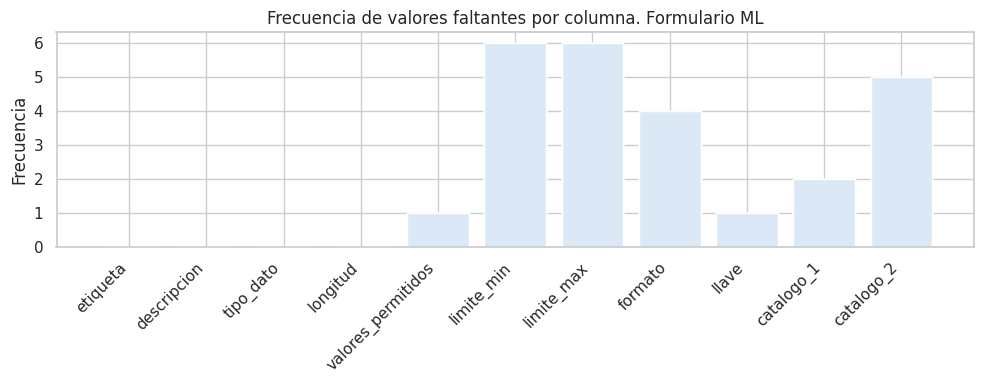

In [ ]:
missing_matrixml = resumen_formml.copy()

plt.figure(figsize=(10, 4))
plt.bar(missing_formml["columna"], missing_formml["n_faltantes"])
plt.xticks(rotation=45, ha="right")
plt.title("Frecuencia de valores faltantes por columna. Formulario ML")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

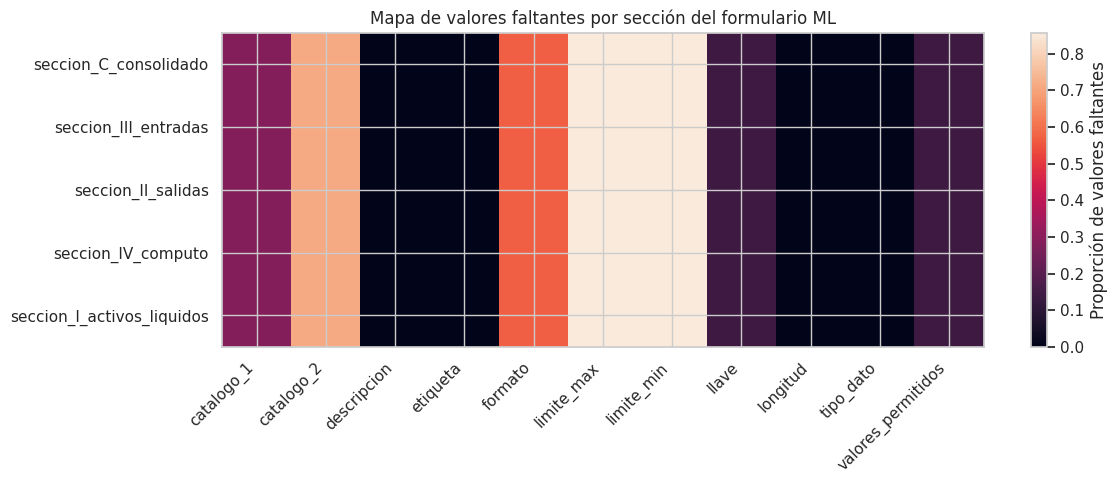

In [ ]:
faltantes_pivot = (
    missing_formml
    .pivot_table(
        index="seccion",
        columns="columna",
        values="porcentaje_faltantes",
        aggfunc="mean"
    )
)

plt.figure(figsize=(12, 5))
plt.imshow(faltantes_pivot.fillna(0), aspect="auto")
plt.colorbar(label="Proporción de valores faltantes")
plt.yticks(range(len(faltantes_pivot.index)), faltantes_pivot.index)
plt.xticks(range(len(faltantes_pivot.columns)), faltantes_pivot.columns, rotation=45, ha="right")
plt.title("Mapa de valores faltantes por sección del formulario ML")
plt.tight_layout()
plt.show()

* __Formulario FE__

In [ ]:
missing_formfe = missing_por_seccion(formulario_fe)
display(missing_formfe.sort_values("porcentaje_faltantes", ascending=False).head(20))

,seccion,columna,n_faltantes,porcentaje_faltantes
6,seccion_I_FED,limite_max,6,0.857143
5,seccion_I_FED,limite_min,6,0.857143
16,seccion_II_fer,limite_min,6,0.857143
17,seccion_II_fer,limite_max,6,0.857143
28,seccion_III_consolidado,limite_max,6,0.857143
27,seccion_III_consolidado,limite_min,6,0.857143
38,seccion_IV_computo_cfen,limite_min,6,0.857143
39,seccion_IV_computo_cfen,limite_max,6,0.857143
21,seccion_II_fer,catalogo_2,5,0.714286
32,seccion_III_consolidado,catalogo_2,5,0.714286


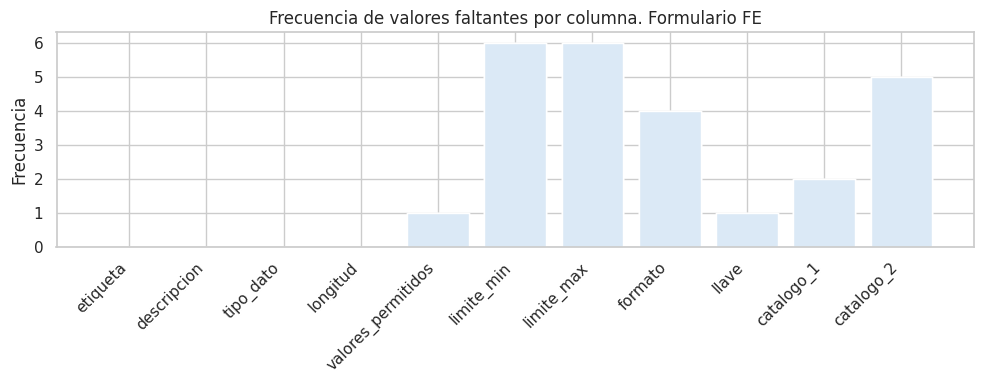

In [ ]:
missing_matrixfe = resumen_formfe.copy()

plt.figure(figsize=(10, 4))
plt.bar(missing_formfe["columna"], missing_formfe["n_faltantes"])
plt.xticks(rotation=45, ha="right")
plt.title("Frecuencia de valores faltantes por columna. Formulario FE")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

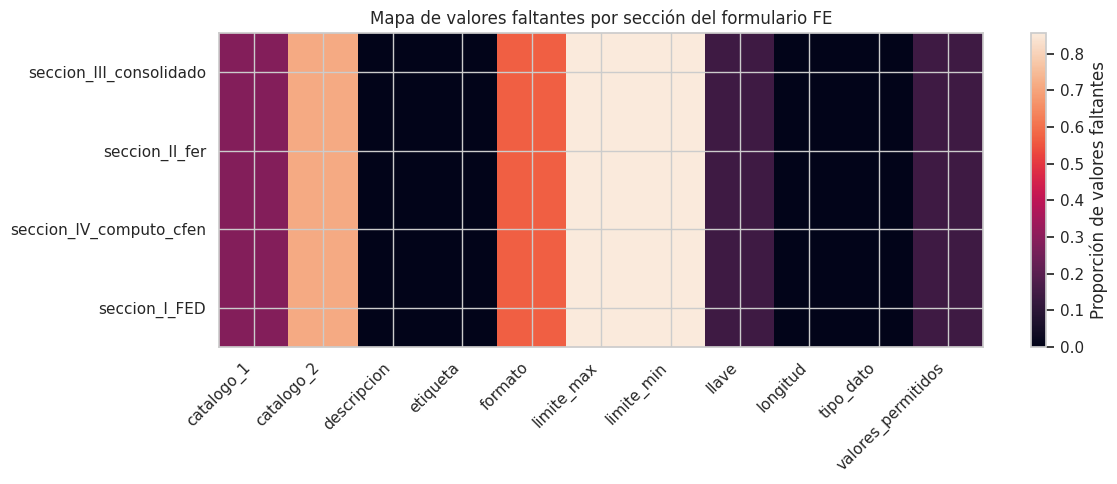

In [ ]:
faltantes_pivot = (
    missing_formfe
    .pivot_table(
        index="seccion",
        columns="columna",
        values="porcentaje_faltantes",
        aggfunc="mean"
    )
)

plt.figure(figsize=(12, 5))
plt.imshow(faltantes_pivot.fillna(0), aspect="auto")
plt.colorbar(label="Proporción de valores faltantes")
plt.yticks(range(len(faltantes_pivot.index)), faltantes_pivot.index)
plt.xticks(range(len(faltantes_pivot.columns)), faltantes_pivot.columns, rotation=45, ha="right")
plt.title("Mapa de valores faltantes por sección del formulario FE")
plt.tight_layout()
plt.show()

* __Formulario LID__

In [ ]:
missing_formlid = missing_por_seccion(formulario_lid)
display(missing_formlid.sort_values("porcentaje_faltantes", ascending=False).head(20))

,seccion,columna,n_faltantes,porcentaje_faltantes
50,seccion_a,catalogo_2,11,1.000000
6,seccion_I_liquiddisp_inicio_dia,limite_max,5,0.833333
25,seccion_IV_corresponsalia,limite_min,8,0.800000
26,seccion_IV_corresponsalia,limite_max,8,0.800000
16,seccion_II_liq_hora_especifica,limite_max,7,0.777778
45,seccion_a,limite_min,8,0.727273
49,seccion_a,catalogo_1,8,0.727273
46,seccion_a,limite_max,8,0.727273
35,seccion_v_usos_lincred,limite_min,10,0.714286
5,seccion_I_liquiddisp_inicio_dia,limite_min,4,0.666667


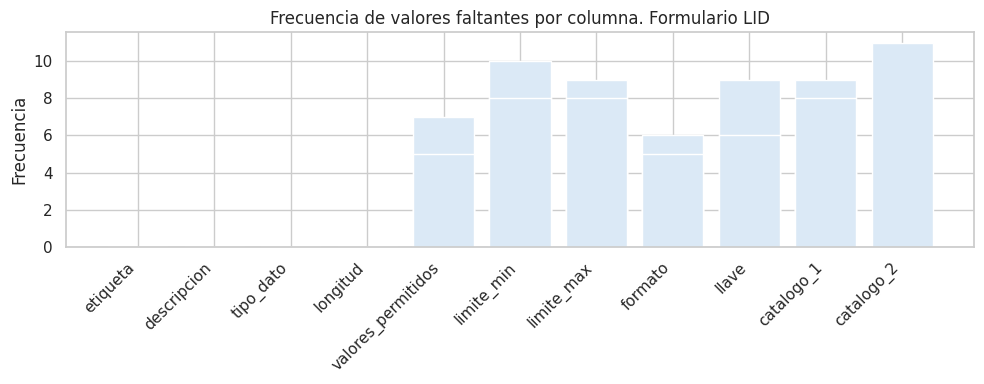

In [ ]:
missing_matrixlid = resumen_formlid.copy()

plt.figure(figsize=(10, 4))
plt.bar(missing_formlid["columna"], missing_formlid["n_faltantes"])
plt.xticks(rotation=45, ha="right")
plt.title("Frecuencia de valores faltantes por columna. Formulario LID")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

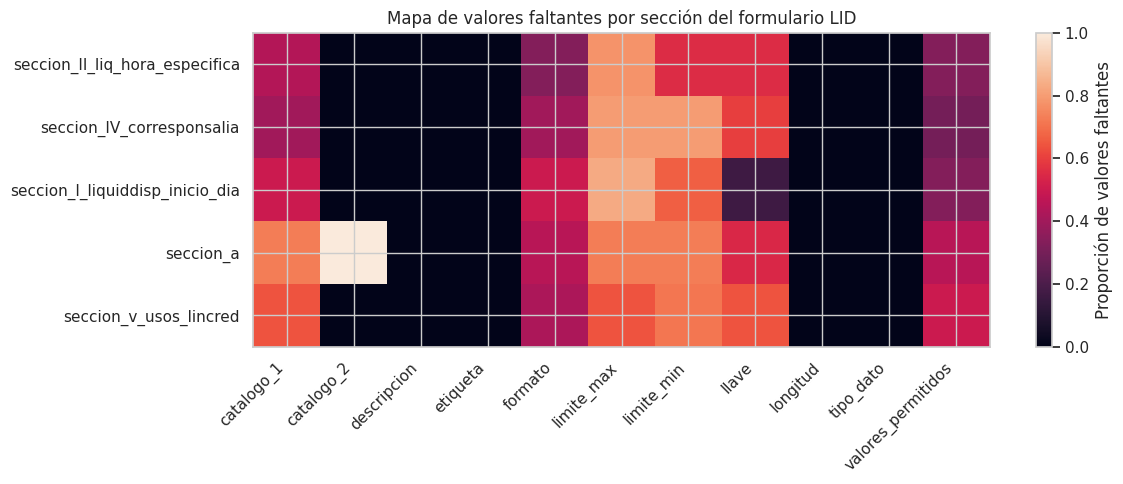

In [ ]:
faltantes_pivot = (
    missing_formlid
    .pivot_table(
        index="seccion",
        columns="columna",
        values="porcentaje_faltantes",
        aggfunc="mean"
    )
)

plt.figure(figsize=(12, 5))
plt.imshow(faltantes_pivot.fillna(0), aspect="auto")
plt.colorbar(label="Proporción de valores faltantes")
plt.yticks(range(len(faltantes_pivot.index)), faltantes_pivot.index)
plt.xticks(range(len(faltantes_pivot.columns)), faltantes_pivot.columns, rotation=45, ha="right")
plt.title("Mapa de valores faltantes por sección del formulario LID")
plt.tight_layout()
plt.show()

## Análisis exploratorio univariante del corpus

En un entorno de NLP, el analisis univariante no se concentra en columnas numéricas convencionales, sino en rasgos estructurales del corpus: longitud de segmentos, cantidad de palabras, densidad de tokens y dispersión de tamaños entre artículos, apartados o párrafos. Esta exploración permite detectar heterogeneidad documental, bloques excesivamente extensos y distribuciones sesgadas que pueden afectar tanto la fragmentación del contexto como el desempeno de modelos posteriores.

La medición descriptiva del corpus cumple una función equivalente a revisar cardinalidad, dispersión y valores extremos en un EDA tabular: antes de modelar, es necesario conocer la forma estadística del insumo textual.

In [ ]:
def segmentar_texto(texto: str) -> list:
    '''
    Función para dividir el texto en segmentos a partir de líneas en blanco, es decir, cada segmento sería un párrafo.
    '''
    segmentos = [bloque.strip() for bloque in re.split(r"\n\s*\n", texto) if bloque.strip()]
    return segmentos

def estadisticas_segmento(texto: str) -> dict:
    '''
    Función para mostrar estadísticas encontradas en cada segmento.
    '''
    palabras = re.findall(r"\b\w+\b", texto, flags=re.UNICODE)
    return {
        "segmento": texto,
        "n_caracteres": len(texto),
        "n_palabras": len(palabras),
        "n_lineas": len(texto.splitlines()),
        "longitud_promedio_palabra": round(
            sum(len(p) for p in palabras) / len(palabras), 2
        ) if palabras else 0
    }



**Formularios en general**

La Ley de Instituciones de Crédito, la Circular 3/2012 emitida por Banco de México, el Anexo 33 de la Circular Única de Bancos, así como otros extractos de dicha circular son documentos regulatorios que norman a todos los formularios desarrollados por la DISF.

A continuación se presentan estadísticas y gráficas de las mismas:


* __Ley de Instituciones de Crédito__

Se tomaron las páginas 93 a 110 que son las que aplican a los formularios.

,count,mean,std,min,25%,50%,75%,max
n_caracteres,410.0,156.634146,188.655578,3.0,32.00,54.500,227.00,993.00
n_palabras,410.0,24.712195,28.923051,0.0,6.00,10.000,36.75,148.00
n_lineas,410.0,1.043902,0.267241,1.0,1.00,1.000,1.00,5.00
longitud_promedio_palabra,410.0,5.282756,1.419153,0.0,4.45,5.115,5.69,8.75


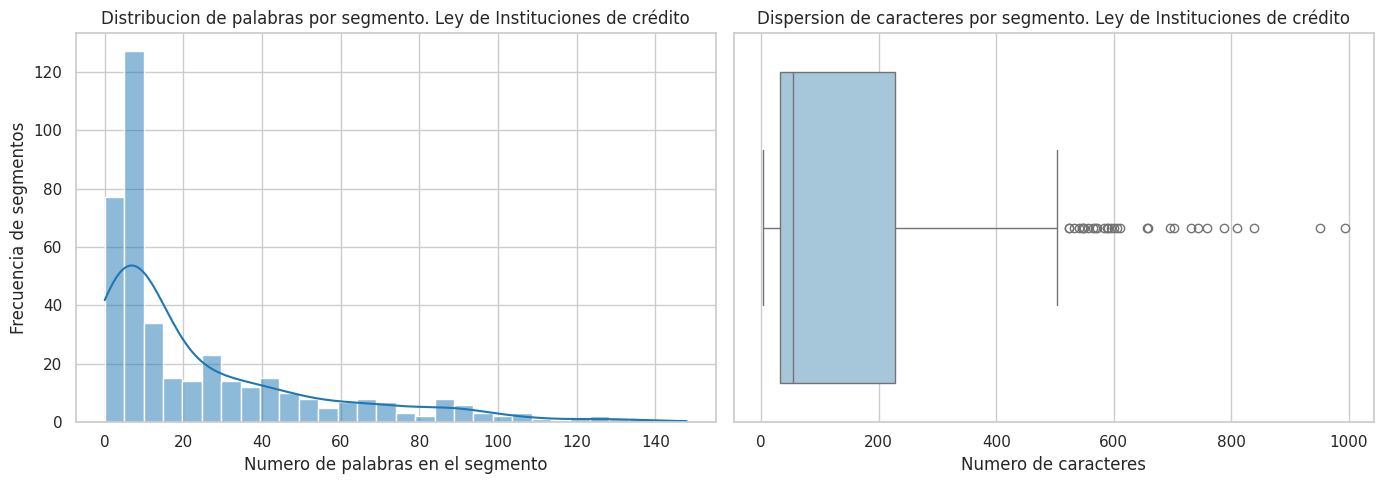

,n_palabras,n_caracteres,segmento
0,148,993,Cuando las instituciones de crédito celebren cesiones o descuentos de cartera crediticia con personas distintas de l...
1,137,951,"f) Utilizar fondos o valores de los fideicomisos, mandatos o comisiones destinados al otorgamiento de créditos, en q..."
2,129,809,XII. Participar en sociedades que no sean de responsabilidad limitada y explotar por su cuenta establecimientos merc...
3,127,838,Artículo 96.- Las instituciones de crédito deberán establecer medidas básicas de seguridad que incluyan la instalaci...
4,126,787,"Con el objeto de preservar la estabilidad financiera, evitar interrupciones o alteraciones en el funcionamiento del ..."


In [ ]:
#reg_lic = MARKDOWN_OUTPUT_DIR / "LeyInstCredito_93-110.md"
reg_lic = markdown_df.loc[
    markdown_df["file_name"] == "LeyInstCredito_93-110.md",
    "text"
].iloc[0]
#texto_crudo_lic = reg_lic.read_text(encoding='utf-8')
texto_crudo_lic = reg_lic
segmentos_crudos_lic = segmentar_texto(texto_crudo_lic)
df_corpus_lic = pd.DataFrame([estadisticas_segmento(s) for s in segmentos_crudos_lic])
display(df_corpus_lic[['n_caracteres', 'n_palabras', 'n_lineas', 'longitud_promedio_palabra']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_corpus_lic, x='n_palabras', bins=30, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribucion de palabras por segmento. Ley de Instituciones de crédito')
axes[0].set_xlabel('Numero de palabras en el segmento')
axes[0].set_ylabel('Frecuencia de segmentos')

sns.boxplot(data=df_corpus_lic, x='n_caracteres', ax=axes[1], color='#9ecae1')
axes[1].set_title('Dispersion de caracteres por segmento. Ley de Instituciones de crédito')
axes[1].set_xlabel('Numero de caracteres')

plt.tight_layout()
plt.show()

segmentos_mas_largos_lic = df_corpus_lic.nlargest(5, 'n_palabras')[['n_palabras', 'n_caracteres', 'segmento']]
display(segmentos_mas_largos_lic.reset_index(drop=True))

* __Circular 3/2012__

,count,mean,std,min,25%,50%,75%,max
n_caracteres,3719.0,202.571121,251.333760,1.0,30.00,111.00,288.00,2713.0
n_palabras,3719.0,32.347405,40.726984,0.0,4.00,18.00,46.00,451.0
n_lineas,3719.0,1.276687,1.464506,1.0,1.00,1.00,1.00,37.0
longitud_promedio_palabra,3719.0,5.159287,1.644822,0.0,4.35,5.04,5.64,25.0


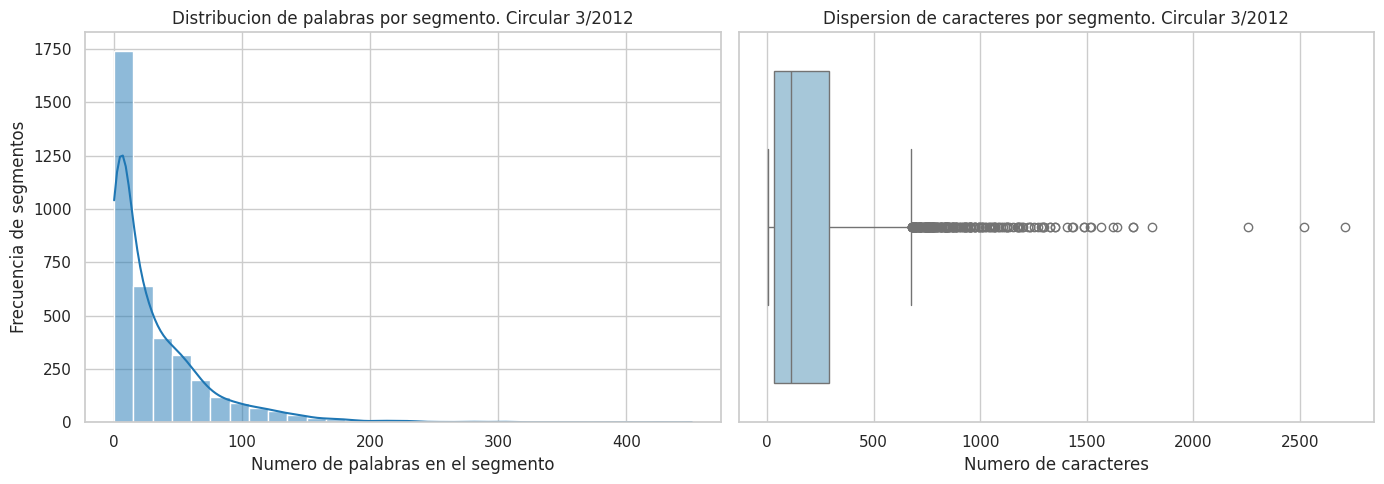

,n_palabras,n_caracteres,segmento
0,451,2713,En caso de que el crédito o préstamo que dicha Institución o SOFOM E.R. Vinculada ofrezca con la intención de que se...
1,423,2518,Artículo 195 Bis 7.- En el evento que el monto correspondiente a la valuación de los depósitos y títulos objeto de l...
2,342,2255,- Artículo 14.- Niveles de operación (Artículo modificado por la Circular 4/2022)\n- Artículo 14 Bis.- Depósitos a l...
3,308,1566,| Fecha Inicial del Período | Fecha Final del Período |\n| --- | --- |\n| 5 de enero de 2023 | 1 de febrero de 20...
4,302,1717,"En la fecha de vencimiento de los reportos, a más tardar, a las 17:55:00 horas, el Banco de México cargará en la Cue..."


In [ ]:
#reg_32012 = MARKDOWN_OUTPUT_DIR / "Circular3-2012.md"
reg_32012 = markdown_df.loc[
    markdown_df["file_name"] == "Circular3-2012.md",
    "text"
].iloc[0]
#texto_crudo_32012 = reg_32012.read_text(encoding='utf-8')
texto_crudo_32012 = reg_32012
segmentos_crudos_32012 = segmentar_texto(texto_crudo_32012)
df_corpus_32012 = pd.DataFrame([estadisticas_segmento(s) for s in segmentos_crudos_32012])
display(df_corpus_32012[['n_caracteres', 'n_palabras', 'n_lineas', 'longitud_promedio_palabra']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_corpus_32012, x='n_palabras', bins=30, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribucion de palabras por segmento. Circular 3/2012')
axes[0].set_xlabel('Numero de palabras en el segmento')
axes[0].set_ylabel('Frecuencia de segmentos')

sns.boxplot(data=df_corpus_32012, x='n_caracteres', ax=axes[1], color='#9ecae1')
axes[1].set_title('Dispersion de caracteres por segmento. Circular 3/2012')
axes[1].set_xlabel('Numero de caracteres')

plt.tight_layout()
plt.show()

segmentos_mas_largos_32012 = df_corpus_32012.nlargest(5, 'n_palabras')[['n_palabras', 'n_caracteres', 'segmento']]
display(segmentos_mas_largos_32012.reset_index(drop=True))

* __Anexo 33 Circular Única de Bancos__

,count,mean,std,min,25%,50%,75%,max
n_caracteres,1589.0,214.751416,278.303133,1.0,41.00,166.00,305.00,6055.0
n_palabras,1589.0,32.998112,38.418114,0.0,6.00,26.00,48.00,666.0
n_lineas,1589.0,1.308370,2.530780,1.0,1.00,1.00,1.00,77.0
longitud_promedio_palabra,1589.0,5.477174,1.685397,0.0,4.89,5.33,5.91,17.0


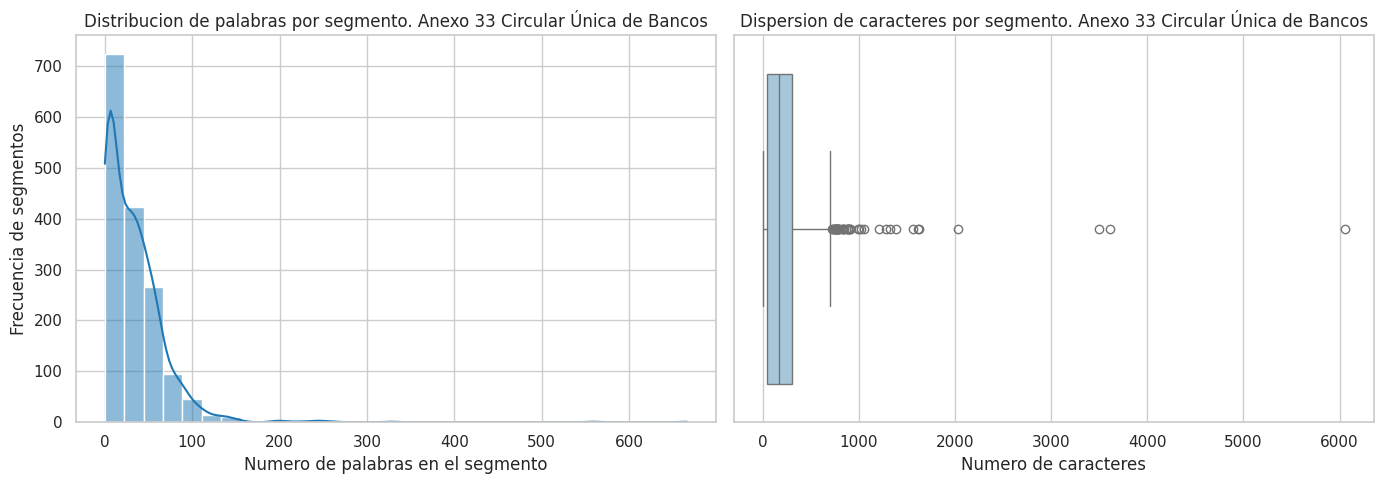

,n_palabras,n_caracteres,segmento
0,666,6055,| ACTIVO | | PASIVO Y CAPITAL | |\n| --- | --- | --- | --- |\n| EFFECTIVO Y EQUIVALENTES DE EFECTIVO | $ | CA...
1,559,3496,"d) principales políticas para clasificar a la cartera de crédito como restringida, así como una breve descripción de..."
2,328,2031,Si un contrato establece que el activo financiero (colateral) se readquirirá a un precio fijo o al precio de venta m...
3,259,1623,"En este tipo de cobertura, la porción cubierta podría ser designada en términos de un monto de divisas (por ejemplo,..."
4,248,3608,| Concepto | Capital contribuido | | | | Capital ganado | | | | | | | | | | | Total parti...


In [ ]:
#reg_a33 = MARKDOWN_OUTPUT_DIR / "Anexo_33_CUB.md"
reg_a33 = markdown_df.loc[
    markdown_df["file_name"] == "Anexo_33_CUB.md",
    "text"
].iloc[0]
#texto_crudo_a33 = reg_a33.read_text(encoding='utf-8')
texto_crudo_a33 = reg_a33
segmentos_crudos_a33 = segmentar_texto(texto_crudo_a33)
df_corpus_a33 = pd.DataFrame([estadisticas_segmento(s) for s in segmentos_crudos_a33])
display(df_corpus_a33[['n_caracteres', 'n_palabras', 'n_lineas', 'longitud_promedio_palabra']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_corpus_a33, x='n_palabras', bins=30, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribucion de palabras por segmento. Anexo 33 Circular Única de Bancos')
axes[0].set_xlabel('Numero de palabras en el segmento')
axes[0].set_ylabel('Frecuencia de segmentos')

sns.boxplot(data=df_corpus_a33, x='n_caracteres', ax=axes[1], color='#9ecae1')
axes[1].set_title('Dispersion de caracteres por segmento. Anexo 33 Circular Única de Bancos')
axes[1].set_xlabel('Numero de caracteres')

plt.tight_layout()
plt.show()

segmentos_mas_largos_a33 = df_corpus_a33.nlargest(5, 'n_palabras')[['n_palabras', 'n_caracteres', 'segmento']]
display(segmentos_mas_largos_a33.reset_index(drop=True))

* __Extracto Circular Única de Bancos__

,count,mean,std,min,25%,50%,75%,max
n_caracteres,483.0,167.716356,303.601652,3.0,38.000,95.0,175.00,3380.00
n_palabras,483.0,27.494824,47.078436,0.0,6.000,17.0,28.00,506.00
n_lineas,483.0,1.821946,2.698812,1.0,1.000,1.0,1.00,37.00
longitud_promedio_palabra,483.0,4.265466,1.228583,0.0,3.565,4.2,5.09,6.96


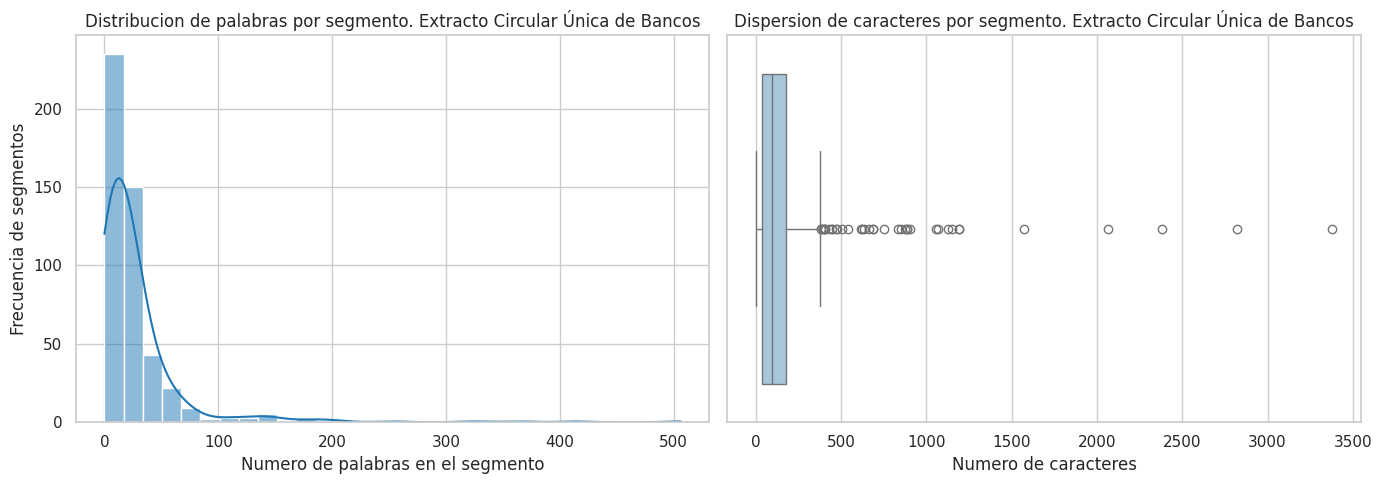

,n_palabras,n_caracteres,segmento
0,506,3380,| Antigüedad del Acreditado en la Institución | Número de meses enteros transcurridos desde la apertura del primer ...
1,413,2819,"| Monto Exigible | El monto que el acreditado debe cubrir en el Periodo de Facturación, el cual deberá considerar t..."
2,364,2379,| Pago Mínimo Exigido | Monto mínimo a la fecha de corte en la cual inicia el Periodo de Pago que el acreditado deb...
3,324,2063,| Tipo de Crédito | Definición |\n| --- | --- |\n| ABCD (B) | A los créditos que sean otorgados a personas física...
4,253,1574,| Reservas Vida Completa_i | = | Monto de reservas a constituir para el i-ésimo crédito en etapa 2. |\n| --- | ---...


In [ ]:
#reg_cub = MARKDOWN_OUTPUT_DIR / "CUB_extracto.md"
reg_cub = markdown_df.loc[
    markdown_df["file_name"] == "CUB_extracto.md",
    "text"
].iloc[0]
#texto_crudo_cub = reg_cub.read_text(encoding='utf-8')
texto_crudo_cub = reg_cub
segmentos_crudos_cub = segmentar_texto(texto_crudo_cub)
df_corpus_cub = pd.DataFrame([estadisticas_segmento(s) for s in segmentos_crudos_cub])
display(df_corpus_cub[['n_caracteres', 'n_palabras', 'n_lineas', 'longitud_promedio_palabra']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_corpus_cub, x='n_palabras', bins=30, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribucion de palabras por segmento. Extracto Circular Única de Bancos')
axes[0].set_xlabel('Numero de palabras en el segmento')
axes[0].set_ylabel('Frecuencia de segmentos')

sns.boxplot(data=df_corpus_cub, x='n_caracteres', ax=axes[1], color='#9ecae1')
axes[1].set_title('Dispersion de caracteres por segmento. Extracto Circular Única de Bancos')
axes[1].set_xlabel('Numero de caracteres')

plt.tight_layout()
plt.show()

segmentos_mas_largos_cub = df_corpus_cub.nlargest(5, 'n_palabras')[['n_palabras', 'n_caracteres', 'segmento']]
display(segmentos_mas_largos_cub.reset_index(drop=True))

**Formulario ML y Formulario FE**

Ademas de los documentos regulatorios anteriores, el formulario ML y el formulario FE surgen a partir de las  Disposiciones de carácter general sobre los Requerimientos de Liquidez para las Instituciones de Banca Múltiple.

* Disposiciones de carácter general sobre los Requerimientos de Liquidez para las Instituciones de Banca Múltiple

,count,mean,std,min,25%,50%,75%,max
n_caracteres,681.0,297.737151,377.007840,3.0,100.00,206.00,372.00,3349.0
n_palabras,681.0,45.903084,55.367059,0.0,15.00,32.00,57.00,528.0
n_lineas,681.0,1.668135,2.510858,1.0,1.00,1.00,1.00,27.0
longitud_promedio_palabra,681.0,5.140044,1.081007,0.0,4.76,5.22,5.64,12.0


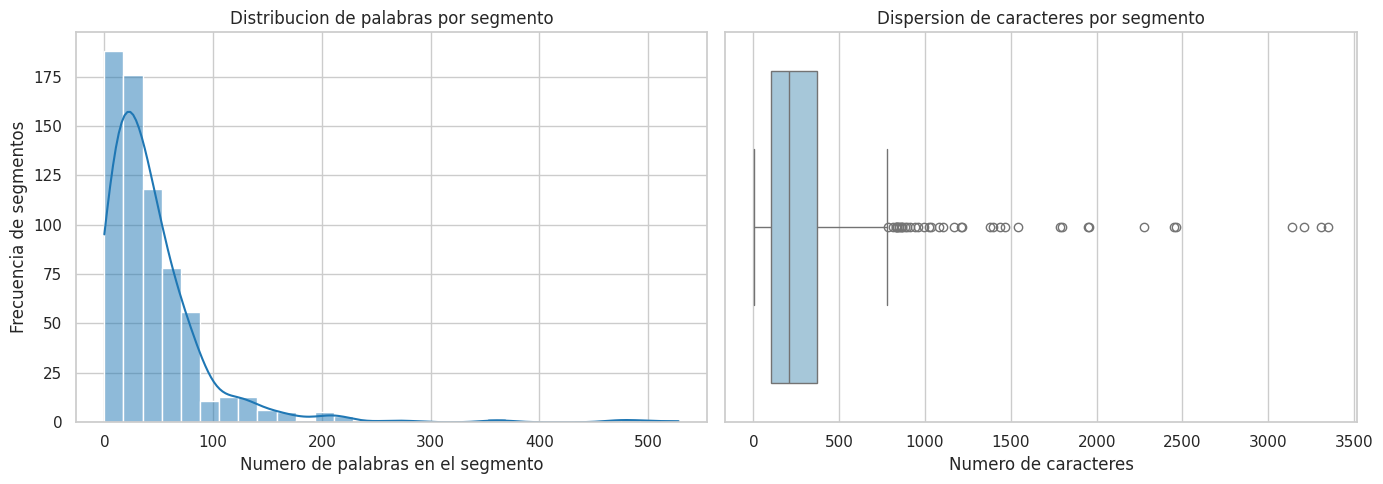

,n_palabras,n_caracteres,segmento
0,528,3349,"| | V.4.1 Activos otorgados en garantía que sean distintos a los activos del Grupo de Nivel I conforme al Anexo 1,..."
1,497,3308,| | operaciones pasivas garantizadas por el IPAB o el que corresponda en la jurisdicción en que se hayan constitui...
2,478,3137,| | I.2.1.1 Monto de Depósitos con Propósitos Operacionales cubierto por el seguro de depósitos del IPAB o por la ...
3,472,3210,"| | II.1 Activos del Grupo de Nivel I conforme al Anexo 1, o bien, cuando el financiamiento proviene del Banco de ..."
4,365,2462,| Referencia | Descripción |\n| --- | --- |\n| 1 | Monto de Activos Líquidos Computables antes de la aplicación d...


In [ ]:
#reg_dliq = MARKDOWN_OUTPUT_DIR / "Disposiciones_Liquidez.md"
reg_dliq = markdown_df.loc[
    markdown_df["file_name"] == "Disposiciones_Liquidez.md",
    "text"
].iloc[0]
#texto_crudo_dliq = reg_dliq.read_text(encoding='utf-8')
texto_crudo_dliq = reg_dliq
segmentos_crudos_dliq = segmentar_texto(texto_crudo_dliq)
df_corpus_dliq = pd.DataFrame([estadisticas_segmento(s) for s in segmentos_crudos_dliq])
display(df_corpus_dliq[['n_caracteres', 'n_palabras', 'n_lineas', 'longitud_promedio_palabra']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_corpus_dliq, x='n_palabras', bins=30, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribucion de palabras por segmento')
axes[0].set_xlabel('Numero de palabras en el segmento')
axes[0].set_ylabel('Frecuencia de segmentos')

sns.boxplot(data=df_corpus_dliq, x='n_caracteres', ax=axes[1], color='#9ecae1')
axes[1].set_title('Dispersion de caracteres por segmento')
axes[1].set_xlabel('Numero de caracteres')

plt.tight_layout()
plt.show()

segmentos_mas_largos_dliq = df_corpus_dliq.nlargest(5, 'n_palabras')[['n_palabras', 'n_caracteres', 'segmento']]
display(segmentos_mas_largos_dliq.reset_index(drop=True))

**Formulario LID**

El formulario LID no cuenta con una norma mexicana. Su diseño surge a partir del documento emitido por el comité de Basilea denominado "Herramientas de monitoreo de la Liquidez Intradía"

* _Herramientas de monitoreo de la Liquidez Intradía_

,count,mean,std,min,25%,50%,75%,max
n_caracteres,190.0,237.163158,248.638812,3.0,60.0000,134.500,363.00,1942.0
n_palabras,190.0,36.184211,35.725182,0.0,10.0000,21.000,56.25,237.0
n_lineas,190.0,1.900000,3.368937,1.0,1.0000,1.000,1.00,35.0
longitud_promedio_palabra,190.0,5.252579,0.935077,0.0,4.9525,5.195,5.65,9.0


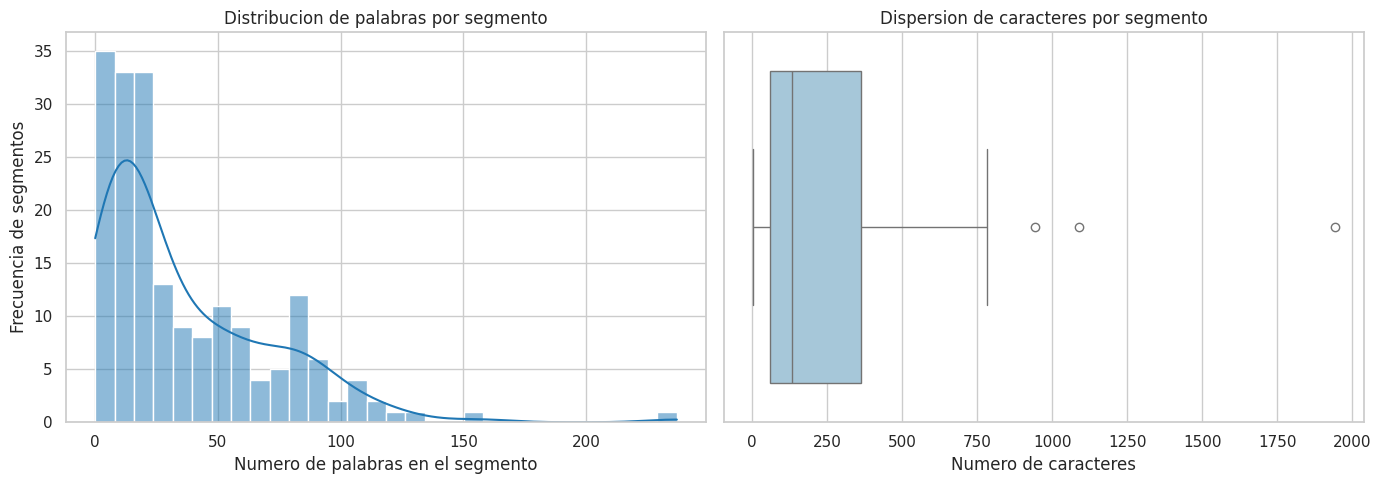

,n_palabras,n_caracteres,segmento
0,237,1942,| Campo / herramienta | Máx./Mín. | 2° | 3° | Prom. |\n| --- | --- | --- | --- | --- |\n| Mes de reporte | | | ...
1,157,942,13. Esta herramienta permitirá a los supervisores monitorear el uso de liquidez intradía de un banco en condiciones ...
2,130,1090,| Campo / herramienta | Máx./Mín. | 2° | 3° | Prom. |\n| --- | --- | --- | --- | --- |\n| A(ii) Liquidez intradía...
3,120,746,"- Liquidez intradía: fondos a los que se puede acceder durante el día hábil, usualmente para permitir que los bancos..."
4,117,783,28. Las herramientas de monitoreo de la Sección III proporcionarán a los supervisores bancarios información sobre el...


In [ ]:
#reg_intl = MARKDOWN_OUTPUT_DIR / "Intraday_liquidity_esp.md"
reg_intl = markdown_df.loc[
    markdown_df["file_name"] == "Intraday_liquidity_esp.md",
    "text"
].iloc[0]
#texto_crudo_intl = reg_intl.read_text(encoding='utf-8')
texto_crudo_intl = reg_intl
segmentos_crudos_intl = segmentar_texto(texto_crudo_intl)
df_corpus_intl = pd.DataFrame([estadisticas_segmento(s) for s in segmentos_crudos_intl])
display(df_corpus_intl[['n_caracteres', 'n_palabras', 'n_lineas', 'longitud_promedio_palabra']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_corpus_intl, x='n_palabras', bins=30, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribucion de palabras por segmento')
axes[0].set_xlabel('Numero de palabras en el segmento')
axes[0].set_ylabel('Frecuencia de segmentos')

sns.boxplot(data=df_corpus_intl, x='n_caracteres', ax=axes[1], color='#9ecae1')
axes[1].set_title('Dispersion de caracteres por segmento')
axes[1].set_xlabel('Numero de caracteres')

plt.tight_layout()
plt.show()

segmentos_mas_largos_intl = df_corpus_intl.nlargest(5, 'n_palabras')[['n_palabras', 'n_caracteres', 'segmento']]
display(segmentos_mas_largos_intl.reset_index(drop=True))

## Análisis exploratorio univariante de los formularios

El análisis univariante de los formularios permite observar la complejidad estructural de cada sección, la distribución de tipos de dato y la reutilización de campos. Esta información es relevante porque el modelo futuro deberá aprender no solo a extraer conceptos regulatorios, sino también a traducirlos en estructuras tabulares coherentes.


**Formulario ML**

In [ ]:
campos = []

for seccion, df in formulario_ml.items():
    temp = df.copy()
    temp["seccion"] = seccion
    campos.append(temp)

df_camposml = pd.concat(campos, ignore_index=True)

display(df_camposml.head())
print(f"Total de campos definidos en el formulario: {len(df_camposml)}")
print(f"Campos únicos por etiqueta: {df_camposml['etiqueta'].nunique() if 'etiqueta' in df_camposml.columns else 'No disponible'}")

,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1,catalogo_2,seccion
0,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN,NaN,seccion_I_activos_liquidos
1,institucion,clave de la institucion a la cual pertenece la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_financieras_ml,NaN,seccion_I_activos_liquidos
2,filial,clave de la entidad financiera objeto de consolidacion asociada a la institucion a la cual corresponde la informacion,caracter,6,valores de catalogo,NaN,NaN,NaN,*,relacion_institucion_filial,NaN,seccion_I_activos_liquidos
3,concepto,clave del concepto de la seccion I al cual corresponde la informacion,numerico,5,valores de catalogo,NaN,NaN,NaN,*,conceptos_ml,concepto_seccion_plazo_ml,seccion_I_activos_liquidos
4,moneda,clave de la moneda,caracter,3,valores de catalogo,NaN,NaN,NaN,*,moneda,NaN,seccion_I_activos_liquidos


Total de campos definidos en el formulario: 35
Campos únicos por etiqueta: 7


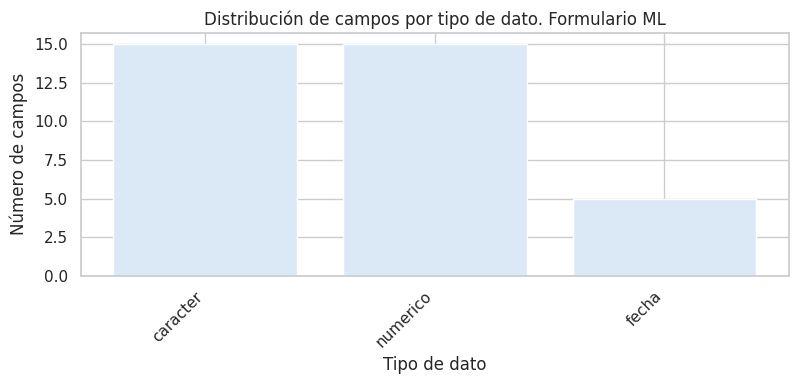

,conteo,count
0,caracter,15
1,numerico,15
2,fecha,5


In [ ]:
if "tipo_dato" in df_camposml.columns:
    tipo_counts = df_camposml["tipo_dato"].fillna("sin_tipo").value_counts()

    plt.figure(figsize=(8, 4))
    plt.bar(tipo_counts.index.astype(str), tipo_counts.values)
    plt.title("Distribución de campos por tipo de dato. Formulario ML")
    plt.xlabel("Tipo de dato")
    plt.ylabel("Número de campos")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(tipo_counts.reset_index().rename(columns={"index": "tipo_dato", "tipo_dato": "conteo"}))

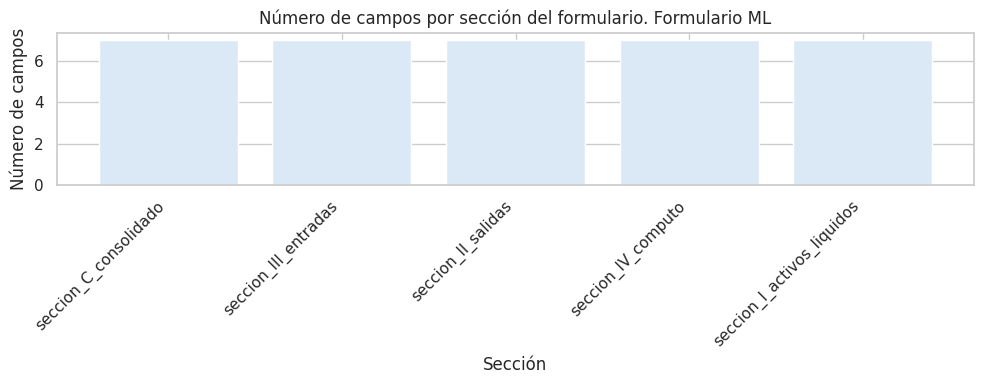

In [ ]:
campos_por_seccion = df_camposml.groupby("seccion").size().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(campos_por_seccion.index, campos_por_seccion.values)
plt.title("Número de campos por sección del formulario. Formulario ML")
plt.xlabel("Sección")
plt.ylabel("Número de campos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Formulario FE**

In [ ]:
campos = []

for seccion, df in formulario_fe.items():
    temp = df.copy()
    temp["seccion"] = seccion
    campos.append(temp)

df_camposfe = pd.concat(campos, ignore_index=True)

display(df_camposfe.head())
print(f"Total de campos definidos en el formulario: {len(df_camposfe)}")
print(f"Campos únicos por etiqueta: {df_camposfe['etiqueta'].nunique() if 'etiqueta' in df_camposfe.columns else 'No disponible'}")

,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1,catalogo_2,seccion
0,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN,NaN,seccion_I_FED
1,institucion,clave de la institucion a la cual corresponde la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_fiancieras_fe,NaN,seccion_I_FED
2,subsidiaria,clave de la subsidiaria de la institucion a la cual corresponde la informacion.,caracter,6,valores de catalogo,NaN,NaN,NaN,*,relacion_institucion_filial,NaN,seccion_I_FED
3,concepto,clave del concepto de la seccion I al cual corresponde la informacion,numerico,5,valores de catalogo,NaN,NaN,NaN,*,conceptos_fe,concepto_seccion_plazo_fe,seccion_I_FED
4,moneda,clave de la moneda,caracter,3,valores de catalogo,NaN,NaN,NaN,*,moneda,NaN,seccion_I_FED


Total de campos definidos en el formulario: 28
Campos únicos por etiqueta: 7


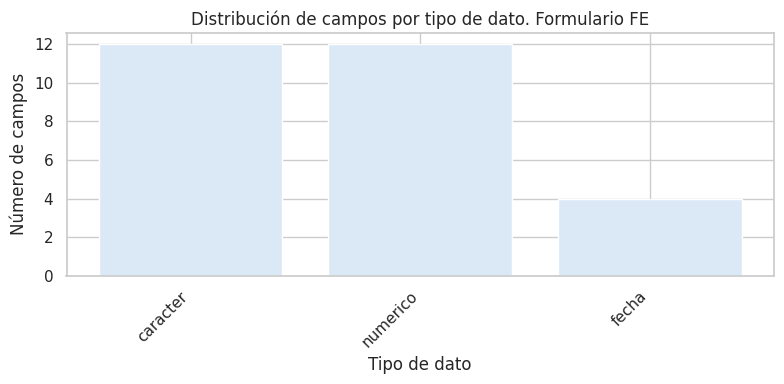

,conteo,count
0,caracter,12
1,numerico,12
2,fecha,4


In [ ]:
if "tipo_dato" in df_camposfe.columns:
    tipo_counts = df_camposfe["tipo_dato"].fillna("sin_tipo").value_counts()

    plt.figure(figsize=(8, 4))
    plt.bar(tipo_counts.index.astype(str), tipo_counts.values)
    plt.title("Distribución de campos por tipo de dato. Formulario FE")
    plt.xlabel("Tipo de dato")
    plt.ylabel("Número de campos")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(tipo_counts.reset_index().rename(columns={"index": "tipo_dato", "tipo_dato": "conteo"}))

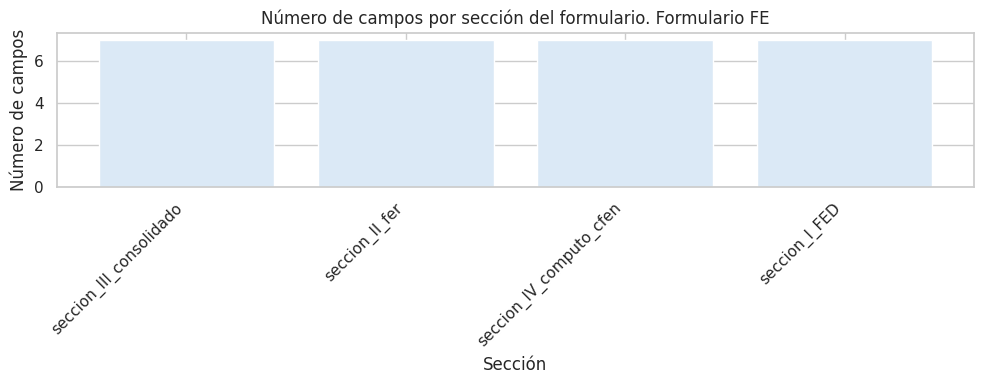

In [ ]:
campos_por_seccion = df_camposfe.groupby("seccion").size().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(campos_por_seccion.index, campos_por_seccion.values)
plt.title("Número de campos por sección del formulario. Formulario FE")
plt.xlabel("Sección")
plt.ylabel("Número de campos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Formulario LID**

In [ ]:
campos = []

for seccion, df in formulario_lid.items():
    temp = df.copy()
    temp["seccion"] = seccion
    campos.append(temp)

df_camposlid = pd.concat(campos, ignore_index=True)

display(df_camposlid.head())
print(f"Total de campos definidos en el formulario: {len(df_camposlid)}")
print(f"Campos únicos por etiqueta: {df_camposlid['etiqueta'].nunique() if 'etiqueta' in df_camposlid.columns else 'No disponible'}")

,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1,seccion,catalogo_2
0,institucion,clave de la institucion a la cual pertenece la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_financieras_lid,seccion_I_liquiddisp_inicio_dia,NaN
1,fecha_corte,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN,seccion_I_liquiddisp_inicio_dia,NaN
2,fecha_datos,fecha de cada dia habil del mes asociado a la fecha_corte,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN,seccion_I_liquiddisp_inicio_dia,NaN
3,clave_tipo,clave para identificar el tipo de informacion a la cual se refiere el registro,numerico,2,valores de catalogo,1.0,NaN,NaN,*,tipo_de_activo_lid,seccion_I_liquiddisp_inicio_dia,NaN
4,saldo,saldo disponible al inicio del dia,numerico,15,valores > 0,0.0,1.000000e+13,NaN,NaN,NaN,seccion_I_liquiddisp_inicio_dia,NaN


Total de campos definidos en el formulario: 50
Campos únicos por etiqueta: 32


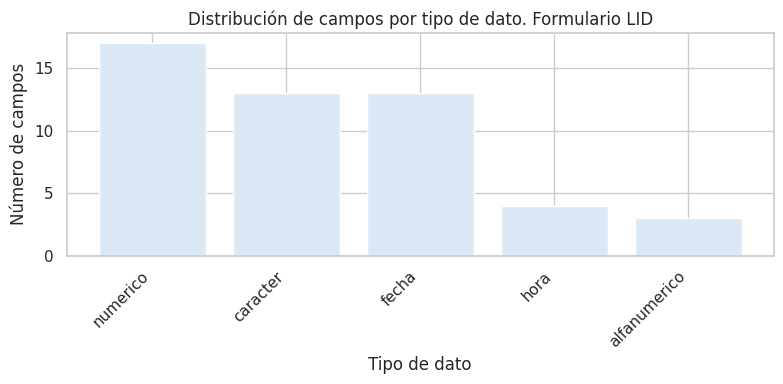

,conteo,count
0,numerico,17
1,caracter,13
2,fecha,13
3,hora,4
4,alfanumerico,3


In [ ]:
if "tipo_dato" in df_camposlid.columns:
    tipo_counts = df_camposlid["tipo_dato"].fillna("sin_tipo").value_counts()

    plt.figure(figsize=(8, 4))
    plt.bar(tipo_counts.index.astype(str), tipo_counts.values)
    plt.title("Distribución de campos por tipo de dato. Formulario LID")
    plt.xlabel("Tipo de dato")
    plt.ylabel("Número de campos")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(tipo_counts.reset_index().rename(columns={"index": "tipo_dato", "tipo_dato": "conteo"}))

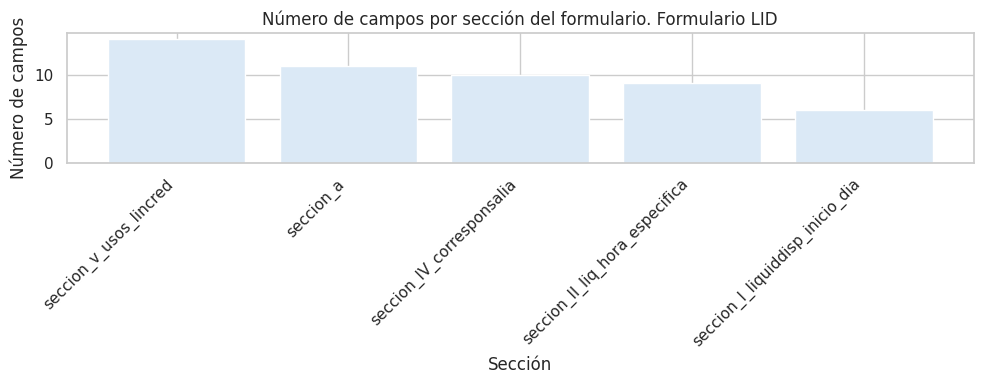

In [ ]:
campos_por_seccion = df_camposlid.groupby("seccion").size().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(campos_por_seccion.index, campos_por_seccion.values)
plt.title("Número de campos por sección del formulario. Formulario LID")
plt.xlabel("Sección")
plt.ylabel("Número de campos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Análisis de cardinalidad de catálogos

La cardinalidad de los catálogos permite estimar la complejidad del espacio de valores permitidos. Catálogos con alta cardinalidad, como conceptos o relaciones entre concepto-sección-plazo, pueden requerir un tratamiento especial en fases posteriores para evitar ambigüedad y mejorar la recuperación de información relevante.


**Formulario ML**

In [ ]:
cardinalidad_catalogos = []

for nombre, df in catalogo_ml.items():
    cardinalidad_catalogos.append({
        "catalogo": nombre,
        "n_registros": len(df),
        "n_columnas": df.shape[1],
        "columnas": ", ".join(df.columns)
    })

df_cardinalidad = pd.DataFrame(cardinalidad_catalogos)
display(df_cardinalidad.sort_values("n_registros", ascending=False))

,catalogo,n_registros,n_columnas,columnas
3,concepto_seccion_plazo_ml,1011,4,"concepto, seccion, plazo, ponderador"
2,conceptos_ml,846,2,"concepto, descripcion"
4,moneda,266,3,"clave, moneda, pais"
1,relacion_institucion_filial,73,2,"institucion, filial"
0,entidades_financieras_ml,59,2,"clave, nombre"
5,plazos_ml,9,2,"clave, descripcion"


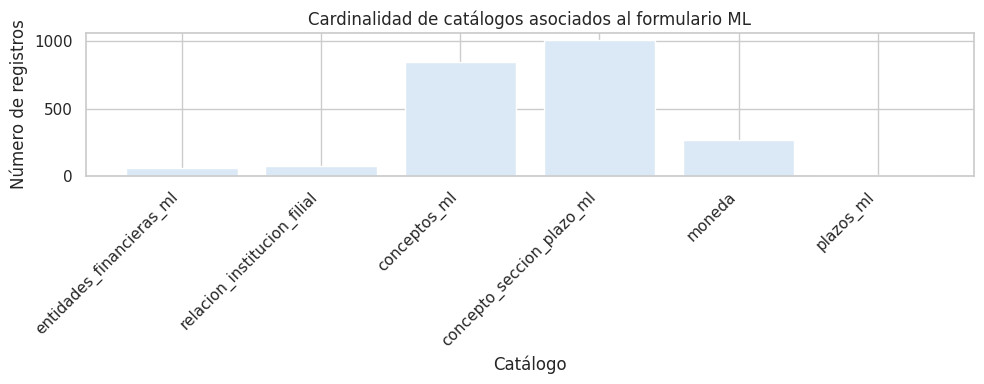

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(df_cardinalidad["catalogo"], df_cardinalidad["n_registros"])
plt.title("Cardinalidad de catálogos asociados al formulario ML")
plt.xlabel("Catálogo")
plt.ylabel("Número de registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Formulario FE**

In [ ]:
cardinalidad_catalogos = []

for nombre, df in catalogo_fe.items():
    cardinalidad_catalogos.append({
        "catalogo": nombre,
        "n_registros": len(df),
        "n_columnas": df.shape[1],
        "columnas": ", ".join(df.columns)
    })

df_cardinalidad = pd.DataFrame(cardinalidad_catalogos)
display(df_cardinalidad.sort_values("n_registros", ascending=False))

,catalogo,n_registros,n_columnas,columnas
3,concepto_seccion_plazo_fe,1160,4,"concepto, seccion, plazo, ponderador"
2,conceptos_fe,515,2,"concepto, descripcion"
4,moneda,266,3,"clave, moneda, pais"
1,relacion_institucion_filial,73,2,"institucion, filial"
0,entidades_financieras_fe,53,2,"clave, nombre"
5,plazos_fe,4,2,"clave, descripcion"


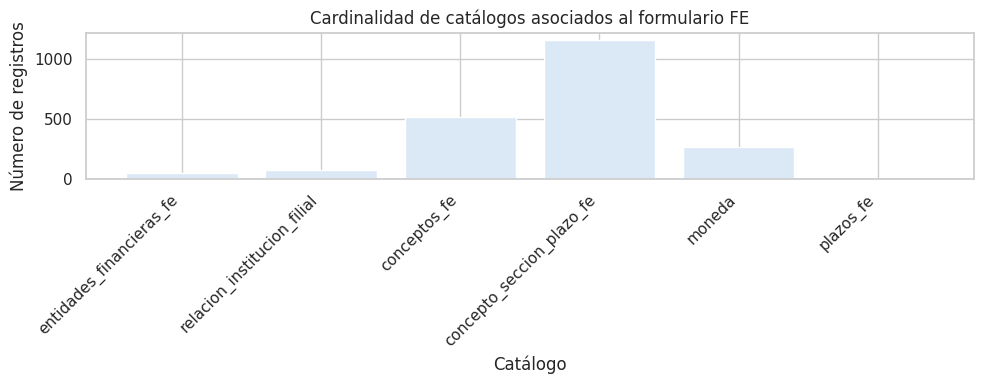

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(df_cardinalidad["catalogo"], df_cardinalidad["n_registros"])
plt.title("Cardinalidad de catálogos asociados al formulario FE")
plt.xlabel("Catálogo")
plt.ylabel("Número de registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Formulario LID**

In [ ]:
cardinalidad_catalogos = []

for nombre, df in catalogo_lid.items():
    cardinalidad_catalogos.append({
        "catalogo": nombre,
        "n_registros": len(df),
        "n_columnas": df.shape[1],
        "columnas": ", ".join(df.columns)
    })

df_cardinalidad = pd.DataFrame(cardinalidad_catalogos)
display(df_cardinalidad.sort_values("n_registros", ascending=False))

,catalogo,n_registros,n_columnas,columnas
2,moneda,267,3,"clave, moneda, pais"
0,entidades_financieras_lid,53,2,"clave, nombre"
12,tipo_garantia_lid,39,3,"clave, descripcion, activo"
1,tipo_de_activo_lid,14,2,"clave, descripcion"
8,tipo_pago_lid,13,2,"clave, descripcion"
7,tipo_obligacion_lid,11,2,"clave, descripcion"
9,liquidaciones_no_efectuadas,7,2,"clave, descripcion"
3,clave_valor_lid,4,2,"clave, descripcion"
4,identificador_pago,2,2,"clave, descripcion"
5,identificador_liquidacion,2,2,"clave, descripcion"


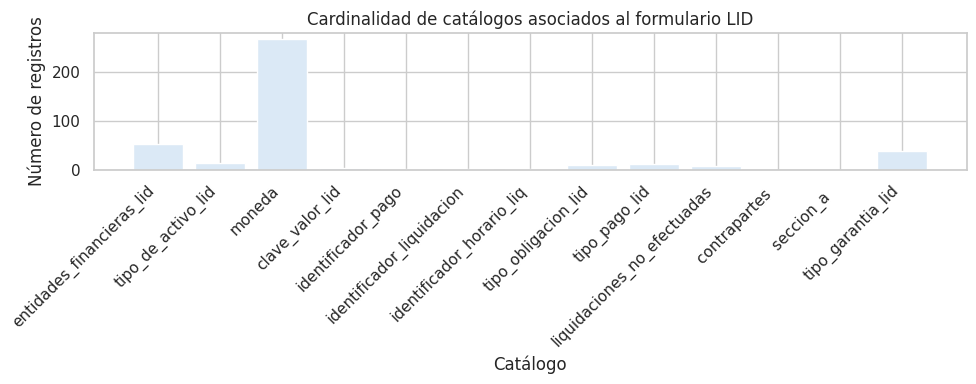

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(df_cardinalidad["catalogo"], df_cardinalidad["n_registros"])
plt.title("Cardinalidad de catálogos asociados al formulario LID")
plt.xlabel("Catálogo")
plt.ylabel("Número de registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Asociación entre secciones y catálogos

Este análisis muestra explícitamente qué catálogos están asociados a cada sección del formulario. Esta relación será fundamental para etapas posteriores, ya que el sistema no debe generar campos de manera aislada, sino estructuras completas donde cada campo tenga, cuando corresponda, un catálogo de valores permitidos.

In [ ]:
def extraer_relacion_seccion_catalogo(formularios: dict) -> pd.DataFrame:
    '''
    Función que verifica los catálogos asociados a cada campo y sección de los formularios.
    '''
    relaciones = []

    for seccion, df in formularios.items():
        columnas_catalogo = [c for c in df.columns if "catalogo" in c]

        for _, row in df.iterrows():
            campo = row.get("etiqueta", None)

            for col_cat in columnas_catalogo:
                catalogo = row.get(col_cat, None)

                if pd.notna(catalogo):
                    relaciones.append({
                        "seccion": seccion,
                        "campo": campo,
                        "columna_catalogo": col_cat,
                        "catalogo": str(catalogo).strip()
                    })

    return pd.DataFrame(relaciones)



**Formulario ML**

In [ ]:
df_relacion_sec_cat_ml = extraer_relacion_seccion_catalogo(formulario_ml)
display(df_relacion_sec_cat_ml)

,seccion,campo,columna_catalogo,catalogo
0,seccion_I_activos_liquidos,institucion,catalogo_1,entidades_financieras_ml
1,seccion_I_activos_liquidos,filial,catalogo_1,relacion_institucion_filial
2,seccion_I_activos_liquidos,concepto,catalogo_1,conceptos_ml
3,seccion_I_activos_liquidos,concepto,catalogo_2,concepto_seccion_plazo_ml
4,seccion_I_activos_liquidos,moneda,catalogo_1,moneda
5,seccion_I_activos_liquidos,plazo,catalogo_1,plazos_ml
6,seccion_I_activos_liquidos,plazo,catalogo_2,concepto_seccion_plazo_ml
7,seccion_II_salidas,institucion,catalogo_1,entidades_financieras_ml
8,seccion_II_salidas,filial,catalogo_1,relacion_institucion_filial
9,seccion_II_salidas,concepto,catalogo_1,conceptos_ml


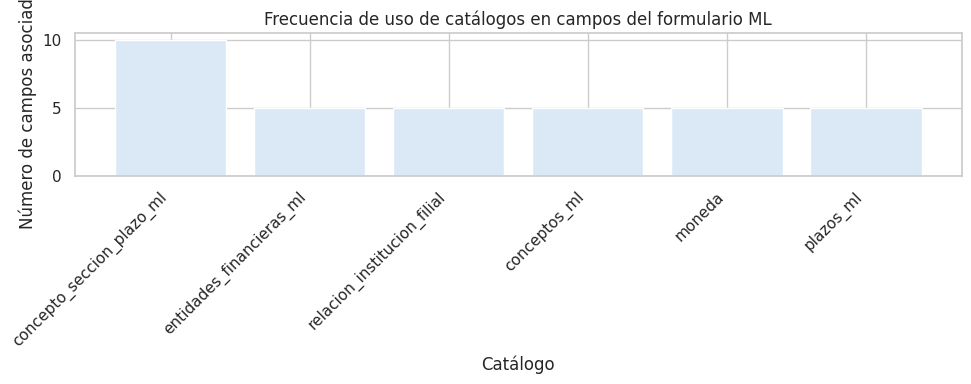

In [ ]:
relaciones_por_catalogo = df_relacion_sec_cat_ml["catalogo"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(relaciones_por_catalogo.index, relaciones_por_catalogo.values)
plt.title("Frecuencia de uso de catálogos en campos del formulario ML")
plt.xlabel("Catálogo")
plt.ylabel("Número de campos asociados")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

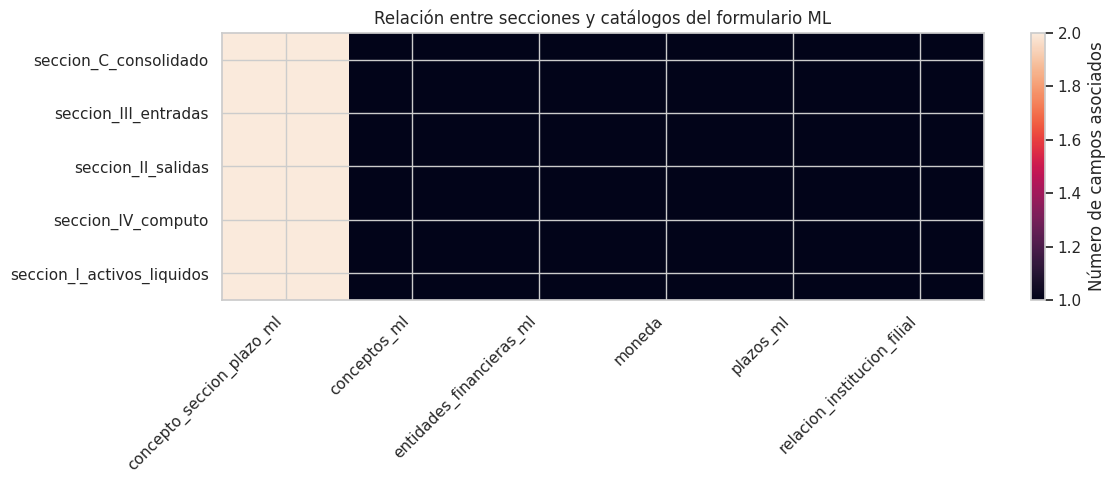

catalogo,concepto_seccion_plazo_ml,conceptos_ml,entidades_financieras_ml,moneda,plazos_ml,relacion_institucion_filial
seccion,,,,,,
seccion_C_consolidado,2,1,1,1,1,1
seccion_III_entradas,2,1,1,1,1,1
seccion_II_salidas,2,1,1,1,1,1
seccion_IV_computo,2,1,1,1,1,1
seccion_I_activos_liquidos,2,1,1,1,1,1


In [ ]:
relacion_matriz = pd.crosstab(df_relacion_sec_cat_ml["seccion"], df_relacion_sec_cat_ml["catalogo"])

plt.figure(figsize=(12, 5))
plt.imshow(relacion_matriz, aspect="auto")
plt.colorbar(label="Número de campos asociados")
plt.yticks(range(len(relacion_matriz.index)), relacion_matriz.index)
plt.xticks(range(len(relacion_matriz.columns)), relacion_matriz.columns, rotation=45, ha="right")
plt.title("Relación entre secciones y catálogos del formulario ML")
plt.tight_layout()
plt.show()

display(relacion_matriz)

**Formulario FE**

In [ ]:
df_relacion_sec_cat_fe = extraer_relacion_seccion_catalogo(formulario_fe)
display(df_relacion_sec_cat_fe)

,seccion,campo,columna_catalogo,catalogo
0,seccion_I_FED,institucion,catalogo_1,entidades_fiancieras_fe
1,seccion_I_FED,subsidiaria,catalogo_1,relacion_institucion_filial
2,seccion_I_FED,concepto,catalogo_1,conceptos_fe
3,seccion_I_FED,concepto,catalogo_2,concepto_seccion_plazo_fe
4,seccion_I_FED,moneda,catalogo_1,moneda
5,seccion_I_FED,plazo,catalogo_1,plazos_fe
6,seccion_I_FED,plazo,catalogo_2,concepto_seccion_plazo_fe
7,seccion_II_fer,institucion,catalogo_1,entidades_fiancieras_fe
8,seccion_II_fer,subsidiaria,catalogo_1,relacion_institucion_filial
9,seccion_II_fer,concepto,catalogo_1,conceptos_fe


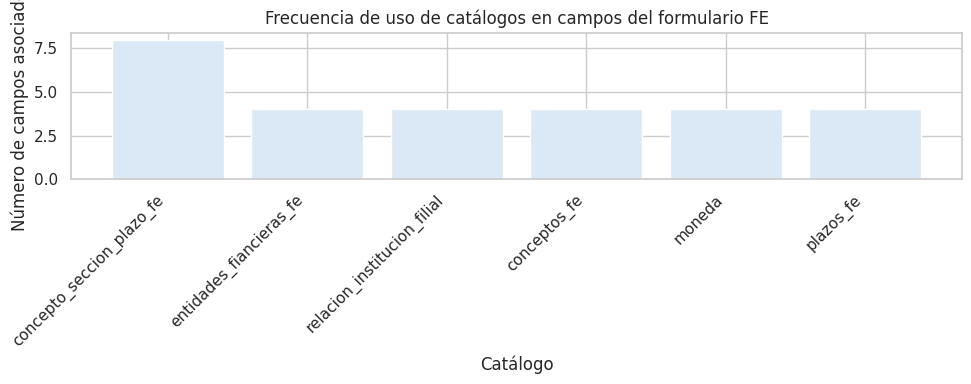

In [ ]:
relaciones_por_catalogo = df_relacion_sec_cat_fe["catalogo"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(relaciones_por_catalogo.index, relaciones_por_catalogo.values)
plt.title("Frecuencia de uso de catálogos en campos del formulario FE")
plt.xlabel("Catálogo")
plt.ylabel("Número de campos asociados")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

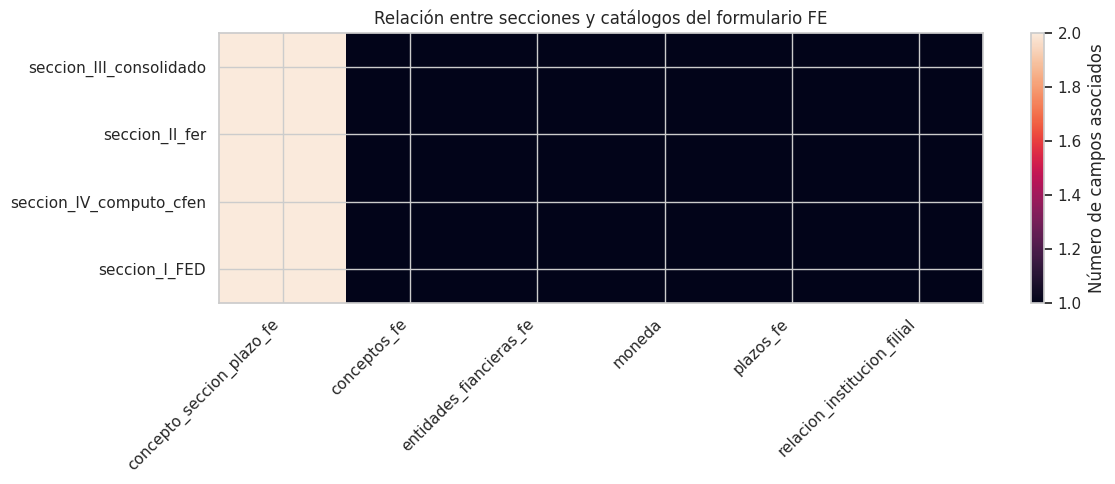

catalogo,concepto_seccion_plazo_fe,conceptos_fe,entidades_fiancieras_fe,moneda,plazos_fe,relacion_institucion_filial
seccion,,,,,,
seccion_III_consolidado,2,1,1,1,1,1
seccion_II_fer,2,1,1,1,1,1
seccion_IV_computo_cfen,2,1,1,1,1,1
seccion_I_FED,2,1,1,1,1,1


In [ ]:
relacion_matriz = pd.crosstab(df_relacion_sec_cat_fe["seccion"], df_relacion_sec_cat_fe["catalogo"])

plt.figure(figsize=(12, 5))
plt.imshow(relacion_matriz, aspect="auto")
plt.colorbar(label="Número de campos asociados")
plt.yticks(range(len(relacion_matriz.index)), relacion_matriz.index)
plt.xticks(range(len(relacion_matriz.columns)), relacion_matriz.columns, rotation=45, ha="right")
plt.title("Relación entre secciones y catálogos del formulario FE")
plt.tight_layout()
plt.show()

display(relacion_matriz)

**Formulario LID**

In [ ]:
df_relacion_sec_cat_lid = extraer_relacion_seccion_catalogo(formulario_lid)
display(df_relacion_sec_cat_lid)

,seccion,campo,columna_catalogo,catalogo
0,seccion_I_liquiddisp_inicio_dia,institucion,catalogo_1,entidades_financieras_lid
1,seccion_I_liquiddisp_inicio_dia,clave_tipo,catalogo_1,tipo_de_activo_lid
2,seccion_I_liquiddisp_inicio_dia,moneda,catalogo_1,moneda
3,seccion_II_liq_hora_especifica,institucion,catalogo_1,entidades_financieras_lid
4,seccion_II_liq_hora_especifica,clave_valor,catalogo_1,clave_valor_lid
5,seccion_II_liq_hora_especifica,tipo_pago,catalogo_1,tipo_obligacion_lid
6,seccion_II_liq_hora_especifica,moneda,catalogo_1,moneda
7,seccion_II_liq_hora_especifica,identificador_pago,catalogo_1,identificador_pago
8,seccion_IV_corresponsalia,institucion,catalogo_1,entidades_financieras_lid
9,seccion_IV_corresponsalia,identificador_pago,catalogo_1,identificador_pago


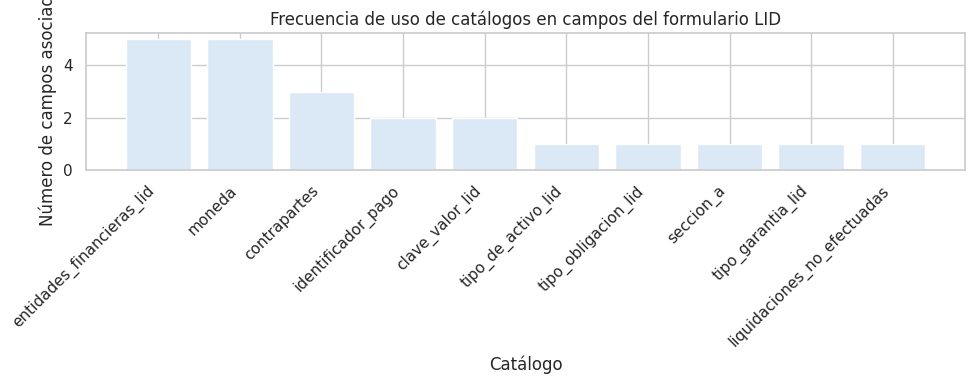

In [ ]:
relaciones_por_catalogo = df_relacion_sec_cat_lid["catalogo"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(relaciones_por_catalogo.index, relaciones_por_catalogo.values)
plt.title("Frecuencia de uso de catálogos en campos del formulario LID")
plt.xlabel("Catálogo")
plt.ylabel("Número de campos asociados")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

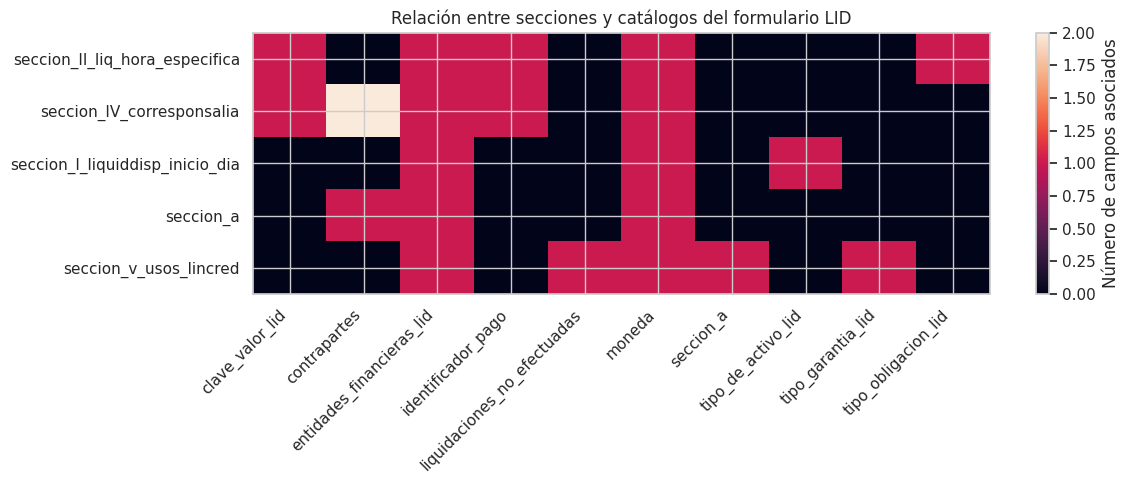

catalogo,clave_valor_lid,contrapartes,entidades_financieras_lid,identificador_pago,liquidaciones_no_efectuadas,moneda,seccion_a,tipo_de_activo_lid,tipo_garantia_lid,tipo_obligacion_lid
seccion,,,,,,,,,,
seccion_II_liq_hora_especifica,1,0,1,1,0,1,0,0,0,1
seccion_IV_corresponsalia,1,2,1,1,0,1,0,0,0,0
seccion_I_liquiddisp_inicio_dia,0,0,1,0,0,1,0,1,0,0
seccion_a,0,1,1,0,0,1,0,0,0,0
seccion_v_usos_lincred,0,0,1,0,1,1,1,0,1,0


In [ ]:
relacion_matriz = pd.crosstab(df_relacion_sec_cat_lid["seccion"], df_relacion_sec_cat_lid["catalogo"])

plt.figure(figsize=(12, 5))
plt.imshow(relacion_matriz, aspect="auto")
plt.colorbar(label="Número de campos asociados")
plt.yticks(range(len(relacion_matriz.index)), relacion_matriz.index)
plt.xticks(range(len(relacion_matriz.columns)), relacion_matriz.columns, rotation=45, ha="right")
plt.title("Relación entre secciones y catálogos del formulario LID")
plt.tight_layout()
plt.show()

display(relacion_matriz)

## Preprocesamiento y tratamiento de ruido documental

Se definen funciones para realizar la limpieza de los textos regulatorios

In [ ]:
def limpieza_universal(texto: str) -> str:
    """
    Limpieza genérica aplicable a cualquier documento normativo extraído.
    Elimina caracteres residuales, dobles espacios y saltos de línea excesivos.
    """
    # Eliminar símbolos residuales extraños de parsers OCR o PDF
    texto = re.sub(r'\^\{\}|\[\]', '', texto)
    texto = re.sub(r'\x0c', ' ', texto) # Saltos de página ocultos

    # Limpiar los saltos de línea excesivos (más de 2 seguidos se vuelven 2)
    texto = re.sub(r'\n{3,}', '\n\n', texto)

    # Quitar espacios múltiples horizontales
    texto = re.sub(r'[ \t]+', ' ', texto)
    return texto.strip()

def limpiar_ruido_cnbv(texto_md: str) -> str:
    """
    Limpia el ruido específico de documentos de la CNBV (ej. Circular Única de Bancos).
    """
    texto = texto_md

    # Quitar las marcas de control de la CNBV al inicio de línea (ej: "(274) ", "(214) ")
    texto = re.sub(r'^\(\d+\)\s*', '', texto, flags=re.MULTILINE)

    # Quitar el pie de página recurrente (dirección y teléfonos de CNBV)
    texto = re.sub(r'Insurgentes Sur 1971.*?www\.gob\.mx/cnbv', '', texto, flags=re.DOTALL)

    # Quitar encabezados institucionales repetitivos de CNBV / SHCP
    patrones = [
        r'^Hacienda Secretaria de Hacienda y Credito Publico$',
        r'^Hacienda Secretaría de Hacienda y Crédito Público$',
        r'^CNBV$',
        r'^CONSEJO NACIONAL.*$'
    ]

    for patron in patrones:
        texto = re.sub(patron, '', texto, flags=re.MULTILINE)

    return texto.strip()

def limpiar_ruido_banxico(texto: str) -> str:
    """
    Limpia ruido específico de documentos del Banco de México (Circulares, disposiciones, etc.)
    Mantiene la estructura normativa (artículos, títulos), eliminando contenido no informativo.
    """
    texto_limpio = texto

    # 1 Eliminar encabezado institucional repetido
    texto_limpio = re.sub(
        r'BANCO\s+DE\s+M[ÉE]XICO.*?\n',
        '',
        texto_limpio,
        flags=re.IGNORECASE)

    # Eliminar bloque de "TEXTO COMPILADO..."
    # (muy largo, no aporta valor semántico)
    texto_limpio = re.sub(
        r'TEXTO\s+COMPILADO.*?respectivamente\.',
        '',
        texto_limpio,
        flags=re.IGNORECASE | re.DOTALL)

    # Eliminar notas de modificación
    texto_limpio = re.sub(
        r'\(Modificado.*?\)',
        '',
        texto_limpio,
        flags=re.IGNORECASE
    )

    # 4. Eliminar números de página aislados
    texto_limpio = re.sub(
        r'\n\s*\d+\s*\n',
        '\n',
        texto_limpio)

    # Normalizar artículos (quitar numeración duplicada tipo "(275)")
    texto_limpio = re.sub(
        r'\(\d+\)\s*Artículo',
        'Artículo',
        texto_limpio)

    # Eliminar líneas completamente en blanco múltiples
    texto_limpio = re.sub(
        r'\n{3,}',
        '\n\n',
        texto_limpio)

    # Normalizar espacios
    texto_limpio = re.sub(
        r'[ \t]+',
        ' ',
        texto_limpio)

    return texto_limpio.strip()

def limpiar_ruido_dof(text: str) -> str:
    text = text.replace('\n', ' ')

    # Quitar encabezados institucionales repetitivos de CNBV / SHCP
    patterns_headers = [
        r'CÁMARA DE DIPUTADOS.*?SERVICIOS PARLAMENTARIOS',
        r'LEY DE INSTITUCIONES DE CRÉDITO',
        r'ESTADOS UNIDOS MEXICANOS',
        r'Última Reforma DOF.*?\d{4}'
    ]

    for p in patterns_headers:
        text = re.sub(p, '', text, flags=re.IGNORECASE)

    # Remover anotaciones legales
    patterns_dof = [
        r'Párrafo reformado DOF.*?\d{4}',
        r'Artículo reformado DOF.*?\d{4}',
        r'Artículo adicionado DOF.*?\d{4}',
        r'Fracción reformada DOF.*?\d{4}',
        r'Fracción adicionada DOF.*?\d{4}',
        r'Reforma DOF.*?\d{4}',
        r'Derogado DOF.*?\d{4}'
    ]

    for p in patterns_dof:
        text = re.sub(p, '', text)

    # Remover número de páginas
    text = re.sub(r'\d+\s+de\s+\d+', '', text)

    # Normalizar espacios
    text = re.sub(r'\s+', ' ', text)

    # Preservar estructura: artículos
    text = re.sub(r'(Artículo\s+\d+\s*(Bis)?\.?)', r'\n\1', text)

    # Preservar números romanos (fracciones)
    text = re.sub(r'\s([IVX]+\.)', r'\n\1', text)

    return text.strip()


def limpiar_ruido_basel(texto: str) -> str:
    """
    Limpia ruido documental típico de documentos del Comité de Basilea/BIS traducidos al español.
    Conserva el contenido normativo principal y elimina portada, avisos, pies de página,
    numeración, ISBN e información editorial.
    """

    texto_limpio = texto

    # Nota de traducción en portada
    texto_limpio = re.sub(
        r"Traducción al español generada.*?Marco de Basilea consolidado\.",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.DOTALL)

    # Encabezado/pie repetido con título del documento
    texto_limpio = re.sub(
        r"Herramientas de monitoreo para la gestión de la liquidez intradía\s*-\s*traducción al español",
        "",
        texto_limpio,
        flags=re.IGNORECASE)

    # Números de página tipo: Página 1 de 16
    texto_limpio = re.sub(
        r"Página\s+\d+\s+de\s+\d+",
        "",
        texto_limpio,
        flags=re.IGNORECASE)

    # Texto editorial de disponibilidad
    texto_limpio = re.sub(
        r"Esta publicación está disponible en el sitio web del BIS.*?\.",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.DOTALL)

    # Copyright / derechos reservados
    texto_limpio = re.sub(
        r"©\s*Banco de Pagos Internacionales\s+2013\..*?cite la fuente\.",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.DOTALL)

    # ISBN
    texto_limpio = re.sub(
        r"ISBN\s+[\d\-Xx]+\s*\(?(impreso|en línea|online|print)?\)?",
        "",
        texto_limpio,
        flags=re.IGNORECASE)

    # Eliminar línea de institución si aparece aislada
    texto_limpio = re.sub(
        r"^\s*Comité de Basilea\s+de Supervisión Bancaria\s*$",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.MULTILINE)

    # Eliminar tabla de contenido / índice con puntos y número de página
    # Ejemplo: "I. Introducción ........................................ 1"
    texto_limpio = re.sub(
        r"^\s*(Contenido|Índice)\s*$",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.MULTILINE)

    texto_limpio = re.sub(
        r"^\s*[IVXLCDM]+\.\s+.*?\.{3,}\s*\d+\s*$",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.MULTILINE)

    texto_limpio = re.sub(
        r"^\s*[A-Z]\.\s+.*?\.{3,}\s*\d+\s*$",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.MULTILINE )

    texto_limpio = re.sub(
        r"^\s*Anexo\s+\d+\..*?\.{3,}\s*\d+\s*$",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.MULTILINE )

    # Quitar números de página aislados
    texto_limpio = re.sub(
        r"\n\s*\d+\s*\n",
        "\n",
        texto_limpio)

    # Normalizar viñetas: mantenerlas, pero limpiar espacios
    texto_limpio = re.sub(
        r"\n\s*[•●]\s*",
        "\n- ",
        texto_limpio)

    # Normalizar espacios y saltos
    texto_limpio = re.sub(r"[ \t]+", " ", texto_limpio)
    texto_limpio = re.sub(r"\n{3,}", "\n\n", texto_limpio)

    return texto_limpio.strip()




def procesar_documento(texto: str, origen: str = "CNBV") -> str:
    if origen.upper() == "CNBV":
        texto = limpieza_universal(limpiar_ruido_cnbv(texto))
    if origen.upper() == "BANXICO":
        texto = limpieza_universal(limpiar_ruido_banxico(texto))
    if origen.upper() == "DOF":
        texto = limpieza_universal(limpiar_ruido_dof(texto))
    if origen.upper() == "BASEL":
        texto = limpieza_universal(limpiar_ruido_basel(texto))
    return limpieza_universal(texto)



**Ley de Instituciones de crédito**

In [ ]:
texto_limpio_lic = procesar_documento(texto_crudo_lic, origen="DOF")

resumen_limpieza_lic = pd.DataFrame({
    "metrica": [
        "Caracteres antes de limpieza",
        "Caracteres después de limpieza",
        "Reducción absoluta",
        "Reducción relativa"
    ],
    "valor": [
        len(texto_crudo_lic),
        len(texto_limpio_lic),
        len(texto_crudo_lic) - len(texto_limpio_lic),
        f"{(len(texto_crudo_lic) - len(texto_limpio_lic)) / len(texto_crudo_lic):.2%}"
    ]
})

display(resumen_limpieza_lic)

,metrica,valor
0,Caracteres antes de limpieza,65038
1,Caracteres después de limpieza,58761
2,Reducción absoluta,6277
3,Reducción relativa,9.65%


A continuación se muestran extractos del texto antes y después de la limpieza

In [ ]:
antes = texto_crudo_lic[:400]
despues = texto_limpio_lic[:400]

In [ ]:
display(Markdown('### Muestra antes de la limpieza. Ley de Instituciones de Crédito.'))
print(antes)
display(Markdown('### Muestra despues de la limpieza. Ley de Instituciones de Crédito.'))
print(despues)

### Muestra antes de la limpieza. Ley de Instituciones de Crédito.

ESTADOS UNIDOS MEXICANOS

CÁMARA DE DIPUTADOS DEL H. CONGRESO DE LA UNIÓN

Secretaría General

Secretaría de Servicios Parlamentarios

LEY DE INSTITUCIONES DE CRÉDITO

Última Reforma DOF 14-11-2025

Las acciones para pedir cuentas, para exigir la responsabilidad de las instituciones de crédito y para pedir la remoción corresponderá al o los fideicomisarios o a sus representantes legales, en cualqu


### Muestra despues de la limpieza. Ley de Instituciones de Crédito.

Las acciones para pedir cuentas, para exigir la responsabilidad de las instituciones de crédito y para pedir la remoción corresponderá al o los fideicomisarios o a sus representantes legales, en cualquier caso, en la medida de sus intereses, y a falta de aquéllos, al Ministerio Público, sin perjuicio de que el fideicomitente pueda reservarse, en el acto constitutivo del fideicomiso o en las modifi


**Circular 3/2012**

In [ ]:
texto_limpio_32012 = procesar_documento(texto_crudo_32012, origen="BANXICO")

resumen_limpieza_32012 = pd.DataFrame({
    "metrica": [
        "Caracteres antes de limpieza",
        "Caracteres después de limpieza",
        "Reducción absoluta",
        "Reducción relativa"
    ],
    "valor": [
        len(texto_crudo_32012),
        len(texto_limpio_32012),
        len(texto_crudo_32012) - len(texto_limpio_32012),
        f"{(len(texto_crudo_32012) - len(texto_limpio_32012)) / len(texto_crudo_32012):.2%}"
    ]
})

display(resumen_limpieza_32012)

,metrica,valor
0,Caracteres antes de limpieza,760798
1,Caracteres después de limpieza,586402
2,Reducción absoluta,174396
3,Reducción relativa,22.92%


A continuación se muestran extractos del texto antes y después de la limpieza

In [ ]:
antes = texto_crudo_32012[:400]
despues = texto_limpio_32012[:400]

In [ ]:
display(Markdown('### Muestra antes de la limpieza. Circular 3/2012.'))
print(antes)
display(Markdown('### Muestra despues de la limpieza. Circular 3/2012.'))
print(despues)

### Muestra antes de la limpieza. Circular 3/2012.

BANCO DE MÉXICO®

TEXTO COMPILADO de la Circular 3/2012 publicada en el Diario Oficial de la Federación el 2 de marzo de 2012, incluyendo sus modificaciones dadas a conocer mediante las circulares 1/2013, 2/2013, 1/2014, 5/2014, 15/2014, 1/2015, 3/2015, 7/2015, 1/2016, 2/2016, 5/2016, 12/2016, 1/2017, 11/2017, 16/2017, 8/2018, 14/2018, 15/2018, 16/2018, 2/2019, 7/2019, 9/2019, 12/2019, 1/2020, 20/


### Muestra despues de la limpieza. Circular 3/2012.

## CIRCULAR 3/2012

## DISPOSICIONES APLICABLES A LAS OPERACIONES DE LAS INSTITUCIONES DE CRÉDITO, LAS SOCIEDADES FINANCIERAS DE OBJETO MÚLTIPLE REGULADAS QUE MANTENGAN VÍNCULOS PATRIMONIALES CON INSTITUCIONES DE CRÉDITO Y LA FINANCIERA NACIONAL DE DESARROLLO AGROPECUARIO, RURAL, FORESTAL Y PESQUERO

## ÍNDICE

## TÍTULO PRIMERO
### DISPOSICIONES PRELIMINARES

## CAPÍTULO ÚNICO
### DISPOSICIONES G


**Anexo 33 Circular Única de Bancos**

In [ ]:
texto_limpio_a33 = procesar_documento(texto_crudo_a33, origen="CNBV")

resumen_limpieza_a33 = pd.DataFrame({
    "metrica": [
        "Caracteres antes de limpieza",
        "Caracteres después de limpieza",
        "Reducción absoluta",
        "Reducción relativa"
    ],
    "valor": [
        len(texto_crudo_a33),
        len(texto_limpio_a33),
        len(texto_crudo_a33) - len(texto_limpio_a33),
        f"{(len(texto_crudo_a33) - len(texto_limpio_a33)) / len(texto_crudo_a33):.2%}"
    ]
})

display(resumen_limpieza_a33)

,metrica,valor
0,Caracteres antes de limpieza,344416
1,Caracteres después de limpieza,343616
2,Reducción absoluta,800
3,Reducción relativa,0.23%


A continuación se muestran extractos del texto antes y después de la limpieza

In [ ]:
antes = texto_crudo_a33[:400]
despues = texto_limpio_a33[:400]

In [ ]:
display(Markdown('### Muestra antes de la limpieza. Anexo 33 Circular Única de Bancos.'))
print(antes)
display(Markdown('### Muestra despues de la limpieza. Anexo 33 Circular Única de Bancos.'))
print(despues)

### Muestra antes de la limpieza. Anexo 33 Circular Única de Bancos.

Pág. 1

(364) ANEXO 33

CONTENIDO

Serie A. Criterios relativos al esquema general de la contabilidad para instituciones de crédito

A - 1 Esquema básico del conjunto de criterios de contabilidad aplicables a instituciones de crédito

A - 2 Aplicación de normas particulares

A - 3 Aplicación de normas generales

A - 4 Aplicación supletoria a los criterios de contabilidad

Serie B. Criterios relati


### Muestra despues de la limpieza. Anexo 33 Circular Única de Bancos.

Pág. 1

ANEXO 33

CONTENIDO

Serie A. Criterios relativos al esquema general de la contabilidad para instituciones de crédito

A - 1 Esquema básico del conjunto de criterios de contabilidad aplicables a instituciones de crédito

A - 2 Aplicación de normas particulares

A - 3 Aplicación de normas generales

A - 4 Aplicación supletoria a los criterios de contabilidad

Serie B. Criterios relativos a 


**Extracto Circular Única de Bancos**

In [ ]:
texto_limpio_cub = procesar_documento(texto_crudo_cub, origen="CNBV")

resumen_limpieza_cub = pd.DataFrame({
    "metrica": [
        "Caracteres antes de limpieza",
        "Caracteres después de limpieza",
        "Reducción absoluta",
        "Reducción relativa"
    ],
    "valor": [
        len(texto_crudo_cub),
        len(texto_limpio_cub),
        len(texto_crudo_cub) - len(texto_limpio_cub),
        f"{(len(texto_crudo_cub) - len(texto_limpio_cub)) / len(texto_crudo_cub):.2%}"
    ]
})

display(resumen_limpieza_cub)

,metrica,valor
0,Caracteres antes de limpieza,81971
1,Caracteres después de limpieza,74611
2,Reducción absoluta,7360
3,Reducción relativa,8.98%


A continuación se muestran extractos del texto antes y después de la limpieza

In [ ]:
antes = texto_crudo_cub[:400]
despues = texto_limpio_cub[:400]

In [ ]:
display(Markdown('### Muestra antes de la limpieza. Extracto Circular Única de Bancos.'))
print(antes)
display(Markdown('### Muestra despues de la limpieza. Extracto Circular Única de Bancos.'))
print(despues)

### Muestra antes de la limpieza. Extracto Circular Única de Bancos.

Hacienda Secretaría de Hacienda y Crédito Público

CNBV

CONSEJO NACIONAL BANCEDAR PRESIDENCIA Y DE VIGILANZA

^{}[]

(275) Artículo 89 Bis.- Las Instituciones, para efecto del cálculo y constitución de las reservas preventivas para riesgos crediticios, deberán calificar desde su reconocimiento inicial los créditos de su Cartera Crediticia con base en el criterio de incremento significativo del ri


### Muestra despues de la limpieza. Extracto Circular Única de Bancos.

Artículo 89 Bis.- Las Instituciones, para efecto del cálculo y constitución de las reservas preventivas para riesgos crediticios, deberán calificar desde su reconocimiento inicial los créditos de su Cartera Crediticia con base en el criterio de incremento significativo del riesgo crediticio. Dicho criterio se aplicará desde el momento de la originación y durante toda la vida del crédito, aun cuand


**Disposiciones de carácter general sobre los Requerimientos de Liquidez para las Instituciones de Banca Múltiple.**

In [ ]:
texto_limpio_dliq = procesar_documento(texto_crudo_dliq, origen="BANXICO")

resumen_limpieza_dliq = pd.DataFrame({
    "metrica": [
        "Caracteres antes de limpieza",
        "Caracteres después de limpieza",
        "Reducción absoluta",
        "Reducción relativa"
    ],
    "valor": [
        len(texto_crudo_dliq),
        len(texto_limpio_dliq),
        len(texto_crudo_dliq) - len(texto_limpio_dliq),
        f"{(len(texto_crudo_dliq) - len(texto_limpio_dliq)) / len(texto_crudo_dliq):.2%}"
    ]
})

display(resumen_limpieza_dliq)

,metrica,valor
0,Caracteres antes de limpieza,204119
1,Caracteres después de limpieza,170035
2,Reducción absoluta,34084
3,Reducción relativa,16.70%


A continuación se muestran extractos del texto antes y después de la limpieza

In [ ]:
antes = texto_crudo_dliq[:400]
despues = texto_limpio_dliq[:400]

In [ ]:
display(Markdown('### Muestra antes de la limpieza. Disposiciones de Liquidez.'))
print(antes)
display(Markdown('### Muestra despues de la limpieza. Disposiciones de Liquidez.'))
print(despues)

### Muestra antes de la limpieza. Disposiciones de Liquidez.

BANCO DE MÉXICO

TEXTO COMPILADO de las Disposiciones de carácter general sobre los Requerimientos de Liquidez para las Instituciones de Banca Múltiple publicadas en el Diario Oficial de la Federación el 23 de agosto de 2021, incluyendo sus modificadas dadas a conocer mediante la Resolución publicada en el referido Diario el 1 de marzo de 2022.

# DISPOSICIONES DE CARÁCTER GENERAL SOBRE LOS REQUER


### Muestra despues de la limpieza. Disposiciones de Liquidez.

Las Instituciones también deberán difundir, en términos del presente artículo, las Políticas y Criterios, así como una lista con la denominación de cada una de las entidades financieras que en apego a las mencionadas Políticas y Criterios, el consejo de administración haya determinado incluir como parte de las Entidades Objeto de Consolidación, así como un listado de aquellas entidades o sociedade


**Herramientas de monitoreo de la Liquidez Intradía**

In [ ]:
texto_limpio_intl = procesar_documento(texto_crudo_intl, origen="BASEL")

resumen_limpieza_intl = pd.DataFrame({
    "metrica": [
        "Caracteres antes de limpieza",
        "Caracteres después de limpieza",
        "Reducción absoluta",
        "Reducción relativa"
    ],
    "valor": [
        len(texto_crudo_intl),
        len(texto_limpio_intl),
        len(texto_crudo_intl) - len(texto_limpio_intl),
        f"{(len(texto_crudo_intl) - len(texto_limpio_intl)) / len(texto_crudo_intl):.2%}"
    ]
})

display(resumen_limpieza_intl)

,metrica,valor
0,Caracteres antes de limpieza,45439
1,Caracteres después de limpieza,42172
2,Reducción absoluta,3267
3,Reducción relativa,7.19%


A continuación se muestran extractos del texto antes y después de la limpieza

In [ ]:
antes = texto_crudo_intl[:400]
despues = texto_limpio_intl[:400]

In [ ]:
display(Markdown('### Muestra antes de la limpieza. Herramientas de monitoreo de la Liquidez Intradía.'))
print(antes)
display(Markdown('### Muestra despues de la limpieza. Herramientas de monitoreo de la Liquidez Intradía.'))
print(despues)

### Muestra antes de la limpieza. Herramientas de monitoreo de la Liquidez Intradía.

Herramientas de monitoreo para la gestión de la liquidez intradía - traducción al español
Página 1 de 16

Comité de Basilea
de Supervisión Bancaria

# Herramientas de monitoreo para la gestión de la liquidez intradía

Abril de 2013

Traducción al español generada a partir del documento en inglés proporcionado por el usuario. El estándar fue integrado al Marco de Basilea consolidado.

Esta publicac


### Muestra despues de la limpieza. Herramientas de monitoreo de la Liquidez Intradía.

# Herramientas de monitoreo para la gestión de la liquidez intradía

Abril de 2013

bis.org).

# Contenido

# I. Introducción

1. La gestión del riesgo de liquidez intradía constituye un elemento clave del marco general de gestión del riesgo de liquidez de un banco. En septiembre de 2008, el Comité de Basilea de Supervisión Bancaria (BCBS) publicó sus Principios para la adecuada gestión y supervis


## Análisis relacional entre regulación, campos y catálogos

El análisis relacional permite observar qué elementos de los formularios y catálogos ya aparecen explícitamente en el texto regulatorio. Esto ayuda a identificar qué componentes podrían derivarse directamente de la regulación y cuáles requieren conocimiento experto adicional o ejemplos históricos.

In [ ]:
def contar_presencia_terminos(terminos, texto):
    '''
    Función para contar el número de términos contenidos en un texto
    '''
    resultados = []

    for termino in terminos:
        if pd.isna(termino):
            continue

        termino = str(termino).strip().lower()
        if len(termino) < 3:
            continue

        ocurrencias = len(re.findall(rf"(?<!\w){re.escape(termino)}(?!\w)", texto))

        if ocurrencias > 0:
            resultados.append({
                "termino": termino,
                "ocurrencias": ocurrencias
            })

    return pd.DataFrame(resultados).sort_values("ocurrencias", ascending=False).drop_duplicates().reset_index(drop=True)

**Regulación general**

Primero se concatenan los corpus de las regulaciones que le aplican a todos los formularios para verificar la relación entre ambos

In [ ]:

texto_crudo_gral = texto_crudo_lic + texto_crudo_32012 + texto_crudo_a33 + texto_crudo_cub
df_corpus_gral = pd.concat([df_corpus_lic+df_corpus_32012+df_corpus_a33+df_corpus_cub],axis=0)

* Relación entre la regulación general y específica con el formulario ML

In [ ]:
texto_crudo_ml = texto_crudo_gral + texto_crudo_dliq
df_corpus_ml = pd.concat([df_corpus_gral,df_corpus_dliq],axis=0)
texto_limpio_ml = re.sub(r"\s+", " ", texto_crudo_ml.lower())

terminos_campos_ml = []

for col in ["etiqueta", "descripcion"]:
    if col in df_camposml.columns:
        terminos_campos_ml.extend(df_camposml[col].dropna().astype(str).tolist())

df_ocurrencias_campos_ml = contar_presencia_terminos(terminos_campos_ml, texto_limpio_ml)

display(df_ocurrencias_campos_ml.head(20))

,termino,ocurrencias
0,monto,558
1,fecha,465
2,plazo,423
3,moneda,256
4,concepto,38
5,filial,15


* Relación entre la regulación general y específica con los catálogos del formulario ML

In [ ]:
%%time
terminos_catalogos_ml = []

for nombre, df in catalogo_ml.items():
    for col in df.columns:
        if df[col].dtype == "object" or pd.api.types.is_string_dtype(df[col]):
            terminos_catalogos_ml.extend(df[col].dropna().astype(str).tolist())

df_ocurrencias_catalogos_ml = contar_presencia_terminos(terminos_catalogos_ml, texto_limpio_ml)

display(df_ocurrencias_catalogos_ml.head(20))

,termino,ocurrencias
0,iii,284
1,base,115
2,coeficiente de cobertura de liquidez,75
3,concepto,38
4,clave,21
5,salidas de efectivo,15
6,consolidado,10
7,avales otorgados,9
8,israel,6
9,otras salidas,4


CPU times: user 1min 19s, sys: 36.3 ms, total: 1min 19s
Wall time: 1min 20s


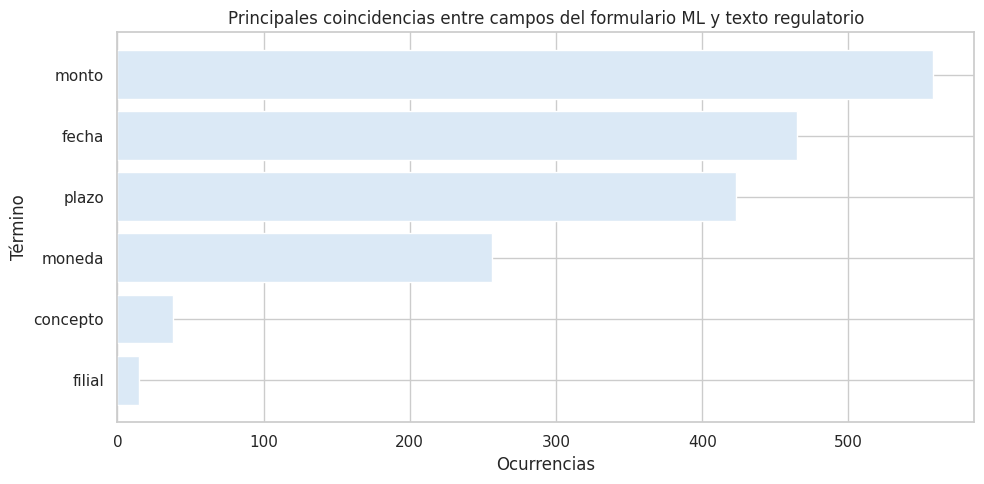

In [ ]:
top_campos = df_ocurrencias_campos_ml.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top_campos["termino"], top_campos["ocurrencias"])
plt.title("Principales coincidencias entre campos del formulario ML y texto regulatorio")
plt.xlabel("Ocurrencias")
plt.ylabel("Término")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

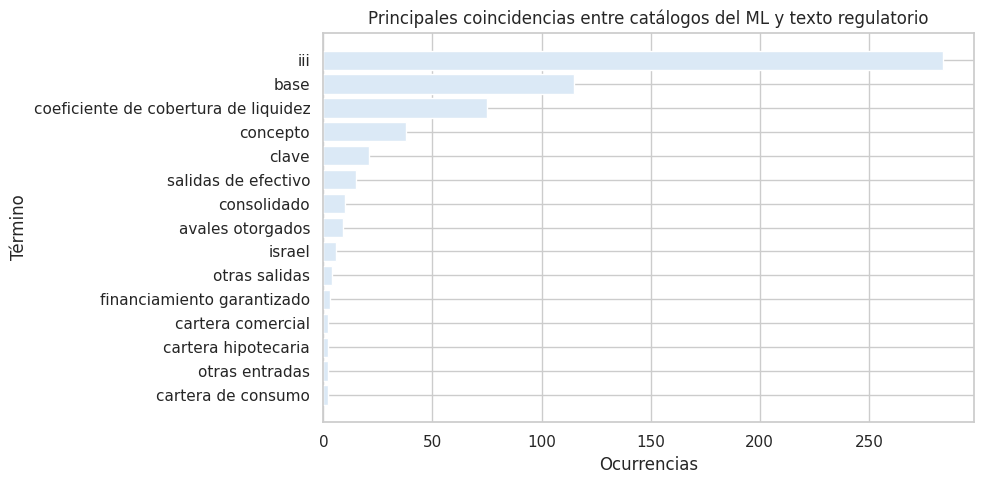

In [ ]:
top_catalogos = df_ocurrencias_catalogos_ml.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top_catalogos["termino"], top_catalogos["ocurrencias"])
plt.title("Principales coincidencias entre catálogos del ML y texto regulatorio")
plt.xlabel("Ocurrencias")
plt.ylabel("Término")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

* Relación entre la regulación general y específica con el formulario FE

In [ ]:
texto_crudo_fe = texto_crudo_gral + texto_crudo_dliq
df_corpus_fe = pd.concat([df_corpus_gral,df_corpus_dliq],axis=0)
texto_limpio_fe = re.sub(r"\s+", " ", texto_crudo_fe.lower())

terminos_campos_fe = []

for col in ["etiqueta", "descripcion"]:
    if col in df_camposfe.columns:
        terminos_campos_fe.extend(df_camposfe[col].dropna().astype(str).tolist())

df_ocurrencias_campos_fe = contar_presencia_terminos(terminos_campos_fe, texto_limpio_fe)

display(df_ocurrencias_campos_fe.head(20))

,termino,ocurrencias
0,monto,558
1,fecha,465
2,plazo,423
3,moneda,256
4,concepto,38
5,subsidiaria,6


In [ ]:
%%time
terminos_catalogos_fe = []

for nombre, df in catalogo_fe.items():
    for col in df.columns:
        if df[col].dtype == "object" or pd.api.types.is_string_dtype(df[col]):
            terminos_catalogos_fe.extend(df[col].dropna().astype(str).tolist())

df_ocurrencias_catalogos_fe = contar_presencia_terminos(terminos_catalogos_fe, texto_limpio_fe)

display(df_ocurrencias_catalogos_fe.head(20))

,termino,ocurrencias
0,iii,284
1,base,115
2,coeficiente de financiamiento estable neto,53
3,bienes adjudicados,20
4,monto de financiamiento estable requerido,18
5,monto de financiamiento estable disponible,14
6,derechos de cobro,13
7,"propiedades, mobiliario y equipo",13
8,avales otorgados,9
9,israel,6


CPU times: user 56.9 s, sys: 48.5 ms, total: 57 s
Wall time: 58.8 s


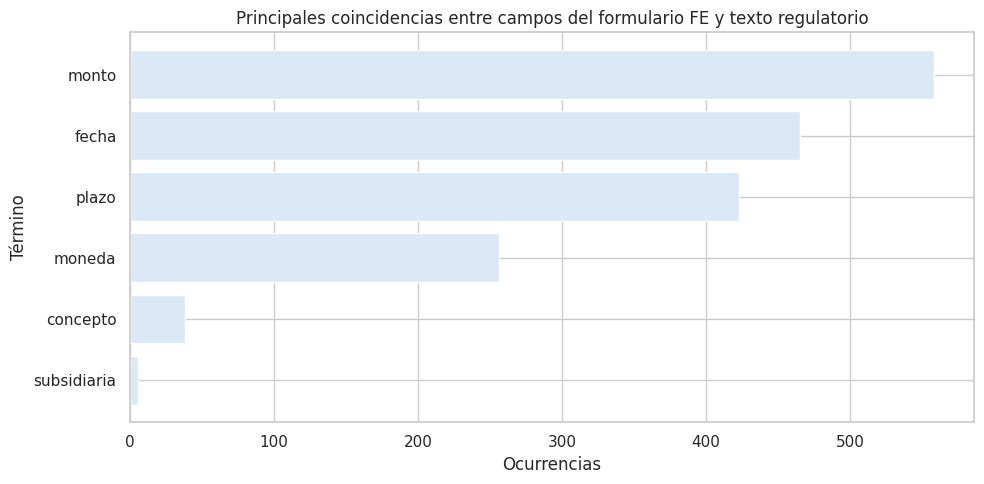

In [ ]:
top_campos = df_ocurrencias_campos_fe.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top_campos["termino"], top_campos["ocurrencias"])
plt.title("Principales coincidencias entre campos del formulario FE y texto regulatorio")
plt.xlabel("Ocurrencias")
plt.ylabel("Término")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

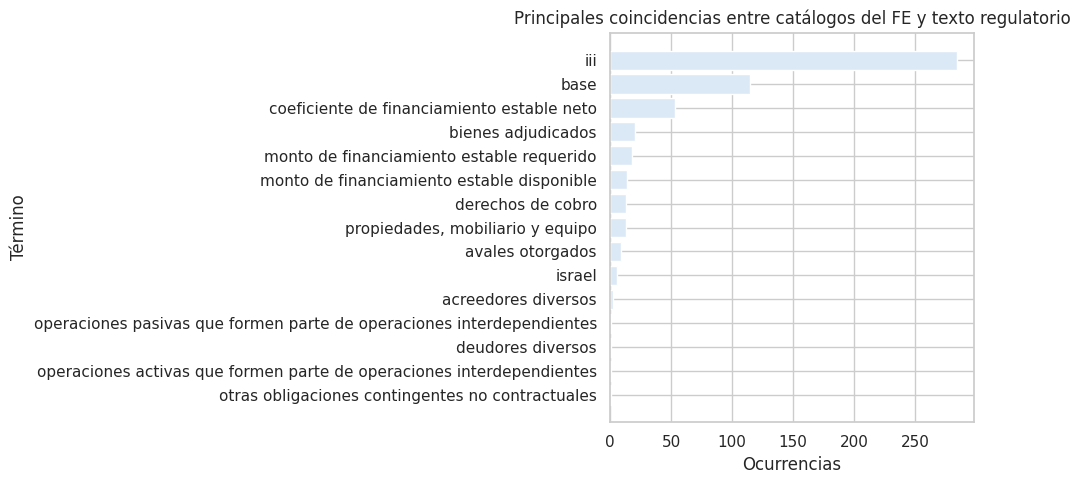

In [ ]:
top_catalogos = df_ocurrencias_catalogos_fe.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top_catalogos["termino"], top_catalogos["ocurrencias"])
plt.title("Principales coincidencias entre catálogos del FE y texto regulatorio")
plt.xlabel("Ocurrencias")
plt.ylabel("Término")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

* Relación entre la regulación general y específica con el formulario LID

In [ ]:
texto_crudo_lid = texto_crudo_gral + texto_crudo_intl
df_corpus_lid = pd.concat([df_corpus_gral,df_corpus_intl],axis=0)
texto_limpio_lid = re.sub(r"\s+", " ", texto_crudo_lid.lower())

terminos_campos_lid = []

for col in ["etiqueta", "descripcion"]:
    if col in df_camposlid.columns:
        terminos_campos_lid.extend(df_camposlid[col].dropna().astype(str).tolist())

df_ocurrencias_campos_lid = contar_presencia_terminos(terminos_campos_lid, texto_limpio_lid)

display(df_ocurrencias_campos_lid.head(20))

,termino,ocurrencias
0,fecha,401
1,monto,389
2,moneda,253
3,saldo,160
4,motivo,36
5,porcentaje,33
6,fecha de vencimiento,21
7,contraparte,19
8,hora,12
9,modifica,2


In [ ]:
%%time
terminos_catalogos_lid = []

for nombre, df in catalogo_lid.items():
    for col in df.columns:
        if df[col].dtype == "object" or pd.api.types.is_string_dtype(df[col]):
            terminos_catalogos_lid.extend(df[col].dropna().astype(str).tolist())

df_ocurrencias_catalogos_lid = contar_presencia_terminos(terminos_catalogos_lid, texto_limpio_lid)

display(df_ocurrencias_catalogos_lid.head(20))

,termino,ocurrencias
0,otros,217
1,base,98
2,acciones,54
3,títulos de deuda,41
4,israel,6
5,bienes muebles,4
6,depósito bancario,2
7,mexico,1
8,sin garantía,1
9,sar,1


CPU times: user 30.6 s, sys: 34.5 ms, total: 30.6 s
Wall time: 31.4 s


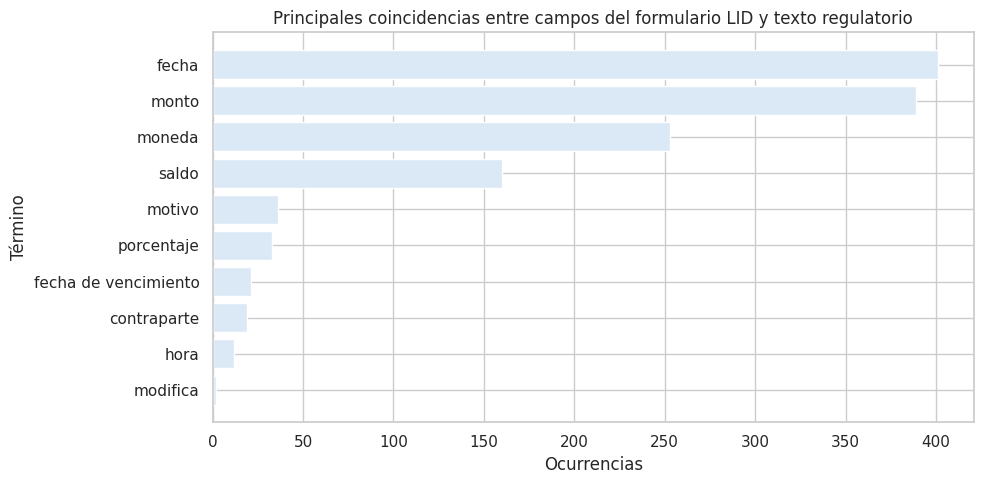

In [ ]:
top_campos = df_ocurrencias_campos_lid.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top_campos["termino"], top_campos["ocurrencias"])
plt.title("Principales coincidencias entre campos del formulario LID y texto regulatorio")
plt.xlabel("Ocurrencias")
plt.ylabel("Término")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

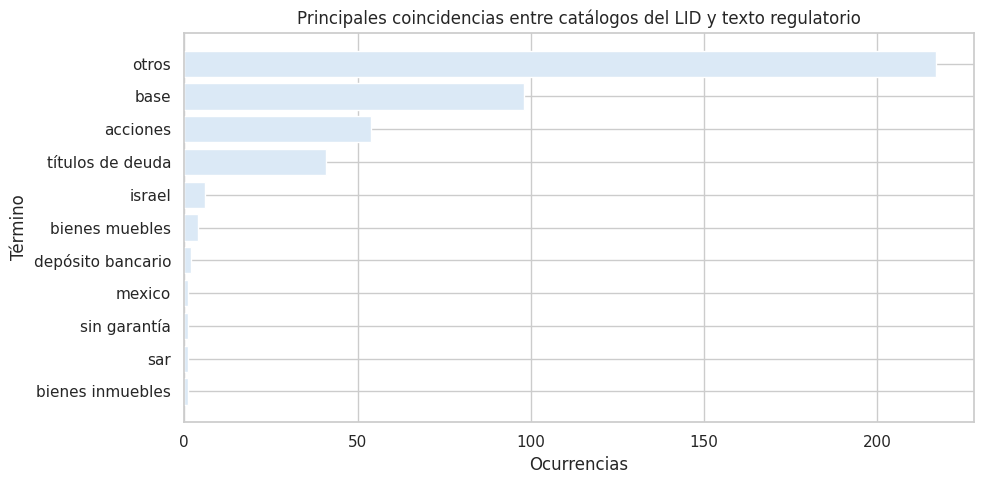

In [ ]:
top_catalogos = df_ocurrencias_catalogos_lid.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top_catalogos["termino"], top_catalogos["ocurrencias"])
plt.title("Principales coincidencias entre catálogos del LID y texto regulatorio")
plt.xlabel("Ocurrencias")
plt.ylabel("Término")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Resumen final del EDA

* Formulario ML

In [ ]:
resumen_final_ml = pd.DataFrame({
    "métrica": [
        "Segmentos regulatorios analizados",
        "Secciones del formulario",
        "Campos totales del formulario",
        "Campos únicos",
        "Catálogos detectados",
        "Registros totales en catálogos",
        "Relaciones sección-campo-catálogo",
        "Caracteres antes de limpieza",
        "Caracteres después de limpieza"
    ],
    "valor": [
        len(df_corpus_ml),
        len(formulario_ml),
        len(df_camposml),
        df_camposml["etiqueta"].nunique() if "etiqueta" in df_camposml.columns else np.nan,
        len(catalogo_ml),
        sum(len(df) for df in catalogo_ml.values()),
        len(df_relacion_sec_cat_ml),
        len(texto_crudo_ml),
        len(texto_limpio_ml)
    ]
})

display(resumen_final_ml)

,métrica,valor
0,Segmentos regulatorios analizados,4400
1,Secciones del formulario,5
2,Campos totales del formulario,35
3,Campos únicos,7
4,Catálogos detectados,6
5,Registros totales en catálogos,2264
6,Relaciones sección-campo-catálogo,35
7,Caracteres antes de limpieza,1456342
8,Caracteres después de limpieza,1446307


* Formulario FE

In [ ]:
resumen_final_fe = pd.DataFrame({
    "métrica": [
        "Segmentos regulatorios analizados",
        "Secciones del formulario",
        "Campos totales del formulario",
        "Campos únicos",
        "Catálogos detectados",
        "Registros totales en catálogos",
        "Relaciones sección-campo-catálogo",
        "Caracteres antes de limpieza",
        "Caracteres después de limpieza"
    ],
    "valor": [
        len(df_corpus_fe),
        len(formulario_fe),
        len(df_camposfe),
        df_camposfe["etiqueta"].nunique() if "etiqueta" in df_camposfe.columns else np.nan,
        len(catalogo_fe),
        sum(len(df) for df in catalogo_fe.values()),
        len(df_relacion_sec_cat_fe),
        len(texto_crudo_fe),
        len(texto_limpio_fe)
    ]
})

display(resumen_final_fe)

,métrica,valor
0,Segmentos regulatorios analizados,4400
1,Secciones del formulario,4
2,Campos totales del formulario,28
3,Campos únicos,7
4,Catálogos detectados,6
5,Registros totales en catálogos,2071
6,Relaciones sección-campo-catálogo,28
7,Caracteres antes de limpieza,1456342
8,Caracteres después de limpieza,1446307


* Formulario LID

In [ ]:
resumen_final_lid = pd.DataFrame({
    "métrica": [
        "Segmentos regulatorios analizados",
        "Secciones del formulario",
        "Campos totales del formulario",
        "Campos únicos",
        "Catálogos detectados",
        "Registros totales en catálogos",
        "Relaciones sección-campo-catálogo",
        "Caracteres antes de limpieza",
        "Caracteres después de limpieza"
    ],
    "valor": [
        len(df_corpus_lid),
        len(formulario_lid),
        len(df_camposlid),
        df_camposlid["etiqueta"].nunique() if "etiqueta" in df_camposlid.columns else np.nan,
        len(catalogo_lid),
        sum(len(df) for df in catalogo_lid.values()),
        len(df_relacion_sec_cat_lid),
        len(texto_crudo_lid),
        len(texto_limpio_lid)
    ]
})

display(resumen_final_lid)

,métrica,valor
0,Segmentos regulatorios analizados,3909
1,Secciones del formulario,5
2,Campos totales del formulario,50
3,Campos únicos,32
4,Catálogos detectados,13
5,Registros totales en catálogos,414
6,Relaciones sección-campo-catálogo,22
7,Caracteres antes de limpieza,1297662
8,Caracteres después de limpieza,1289012


### Conclusión Ampliada del EDA

El análisis exploratorio de datos (EDA) realizado sobre el corpus normativo y los catálogos regulatorios ha proporcionado una comprensión profunda de la naturaleza y la calidad de los insumos principales de este proyecto. Se ha confirmado que, a pesar de la heterogeneidad inherente al texto no estructurado y la diversidad en las estructuras tabulares de formularios y catálogos, los principios del EDA pueden ser eficazmente aplicados en un contexto de Procesamiento de Lenguaje Natural (NLP).

**Hallazgos Principales:**

*   **Calidad del Corpus Normativo:** La depuración del corpus regulatorio eliminó una proporción significativa de ruido documental (encabezados, pies de página, residuos de OCR), lo que resultó en textos más limpios y semánticamente densos. Esta reducción de información no relevante es esencial para mejorar la precisión de los modelos de lenguaje que se emplearán en fases futuras.
*   **Estructura y Heterogeneidad Textual:** La distribución de la longitud de los segmentos textuales evidenció una variabilidad considerable, lo que sugiere que existe una necesidad de estrategias avanzadas de fragmentación y vectorización para optimizar la ingestión de contexto para los LLMs. Identificar y procesar adecuadamente segmentos largos y cortos será fundamental para evitar la pérdida de información o la sobrecarga contextual.
*   **Características de los Formularios:** El análisis univariante de los formularios reveló patrones en la distribución de tipos de datos y la reutilización de campos entre secciones. Esto subraya la importancia de que los modelos no solo extraigan conceptos, sino que también comprendan la lógica estructural subyacente a la construcción de formularios, incluyendo la dependencia de campos específicos de catálogos o rangos de valores.
*   **Cardinalidad y Complejidad de Catálogos:** La exploración de los catálogos destacó una gama diversa en su cardinalidad y complejidad. Catálogos con alta cardinalidad (como `conceptos_ml` o `concepto_seccion_plazo_ml`) representan espacios de valores con gran cantidad de información, que requerirán técnicas robustas de alineación semántica y desambiguación. Aquellos con baja cardinalidad, por otro lado, pueden ser utilizados directamente para validaciones precisas.
*   **Relación Regulación-Formulario-Catálogo:** El análisis relacional, que mapeó términos de campos y catálogos contra el texto regulatorio, confirmó que existe una relación terminológica explícita entre los tres insumos. Esta interconexión es un pilar fundamental para el diseño automatizado, ya que valida que los formularios y catálogos son una formalización estructurada del contenido normativo. Las principales coincidencias brindan un punto de partida sólido para la extracción de entidades y la inferencia de relaciones.

**Implicaciones para Próximas Etapas:**

Los resultados de este EDA no sólo ofrecen una instantánea del estado actual de los datos, sino que también guían las decisiones metodológicas para las fases siguientes. La limpieza de texto asegura un *input* de mayor calidad para el *embedding* y la recuperación de información. La comprensión de la estructura de los formularios y catálogos informará el diseño de agentes inteligentes capaces de generar no solo campos individuales, sino secciones y formularios completos con sus validaciones y dependencias de catálogos. Este avance sienta las bases para un sistema que pueda aprender de manera robusta la lógica regulatoria subyacente y automatizar de forma confiable el diseño de los formularios.